In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
np.random.seed(42)

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# Load raw data
raw_df = pd.read_excel("Utilities.xlsx", sheet_name="Usage")

print(f"Shape: {raw_df.shape}")
print(f"\nColumns: {raw_df.columns.tolist()}")
print(f"\nFirst 3 rows:")
raw_df.head(3)

Shape: (34, 16)

Columns: ['Year', 'Month', 'Gas Use', 'Elec Use', 'Solar Production', 'Elec Import', 'Elec Export', 'EV Charger Use', 'Heating Degree Days', 'Gas Cost', 'Elec Import Cost', 'Export Income', 'Feedback Costs', 'Fixed Costs', 'EV Charger Income', 'Remarks']

First 3 rows:


,Year,Month,Gas Use,Elec Use,Solar Production,Elec Import,Elec Export,EV Charger Use,Heating Degree Days,Gas Cost,Elec Import Cost,Export Income,Feedback Costs,Fixed Costs,EV Charger Income,Remarks
0,2023,May,7,10,26,55,73,0.0,132.67,9.57,21.46,28.58,0.0,4.79,0.0,NaN
1,2023,Jun,26,186,192,132,136,0.0,16.93,35.53,51.38,53.64,0.0,9.59,0.0,NaN
2,2023,Jul,36,241,162,172,97,0.0,5.49,49.19,66.87,38.27,0.0,9.91,0.0,NaN


In [3]:
# ── DATA CLEANING & CALCULATIONS ──────────────────────

# Work on a copy of raw data
df = raw_df.copy()

# STEP 1 - Create proper datetime index
df["Date"] = pd.to_datetime(df["Year"].astype(str) + " " + df["Month"], format="%Y %b")
df = df.set_index("Date")
df = df.drop(columns=["Year", "Month"])

# STEP 2 - Apply sign conventions
# Raw data is all positive — apply signs for calculations
# Outgoing flows become negative
df["Elec Export"] = df["Elec Export"] * -1
df["EV Charger Use"] = df["EV Charger Use"] * -1
df["EV Charger Income"] = df["EV Charger Income"] * -1
df["Export Income"] = df["Export Income"] * -1

# STEP 3 - Derived calculations
df["Gas kWh"] = df["Gas Use"] * 9.77
df["Household Elec"] = df["Elec Use"] - df["EV Charger Use"].abs()
df["Net Grid Use"] = df["Elec Import"] + df["Elec Export"]
df["EV Electricity Cost"] = df["EV Charger Use"].abs() * (df["Elec Import Cost"] / df["Elec Import"])
df["EV Net Profit"] = df["EV Charger Income"].abs() - df["EV Electricity Cost"]
df["Net Position"] = (df["Export Income"] + df["EV Charger Income"].abs() +
                      (df["Gas Cost"] * -1) + (df["Elec Import Cost"] * -1) +
                      (df["Feedback Costs"] * -1) + (df["Fixed Costs"] * -1))
df["Energy Year"] = df.index.map(lambda date: 
    f"EY{date.year + 1}" if date.month >= 7 else f"EY{date.year}")

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Columns: {df.columns.tolist()}")

Shape: (34, 21)
Date range: May 2023 to February 2026
Columns: ['Gas Use', 'Elec Use', 'Solar Production', 'Elec Import', 'Elec Export', 'EV Charger Use', 'Heating Degree Days', 'Gas Cost', 'Elec Import Cost', 'Export Income', 'Feedback Costs', 'Fixed Costs', 'EV Charger Income', 'Remarks', 'Gas kWh', 'Household Elec', 'Net Grid Use', 'EV Electricity Cost', 'EV Net Profit', 'Net Position', 'Energy Year']


In [4]:
# Sanity check key calculated columns
print("── Calculated Column Spot Check ──────────────")
print(f"\nGas kWh (should be Gas Use × 9.77):")
print(df[["Gas Use", "Gas kWh"]].tail(5).to_string())

print(f"\nHousehold Elec (should be Elec Use minus EV charging):")
print(df[["Elec Use", "EV Charger Use", "Household Elec"]].tail(5).to_string())

print(f"\nEV Net Profit (should be income minus electricity cost):")
print(df[["EV Charger Income", "EV Electricity Cost", "EV Net Profit"]].tail(5).to_string())

print(f"\nEnergy Year labels:")
print(df[["Energy Year"]].tail(10).to_string())

── Calculated Column Spot Check ──────────────

Gas kWh (should be Gas Use × 9.77):
            Gas Use  Gas kWh
Date                        
2025-10-01        3    29.31
2025-11-01        4    39.08
2025-12-01        2    19.54
2026-01-01        3    29.31
2026-02-01        2    19.54

Household Elec (should be Elec Use minus EV charging):
            Elec Use  EV Charger Use  Household Elec
Date                                                
2025-10-01       963         -428.78          534.22
2025-11-01      1063         -349.00          714.00
2025-12-01      1351         -453.58          897.42
2026-01-01       851          -67.33          783.67
2026-02-01       910         -258.85          651.15

EV Net Profit (should be income minus electricity cost):
            EV Charger Income  EV Electricity Cost  EV Net Profit
Date                                                             
2025-10-01            -165.19           124.715194      40.474806
2025-11-01            -133.29 

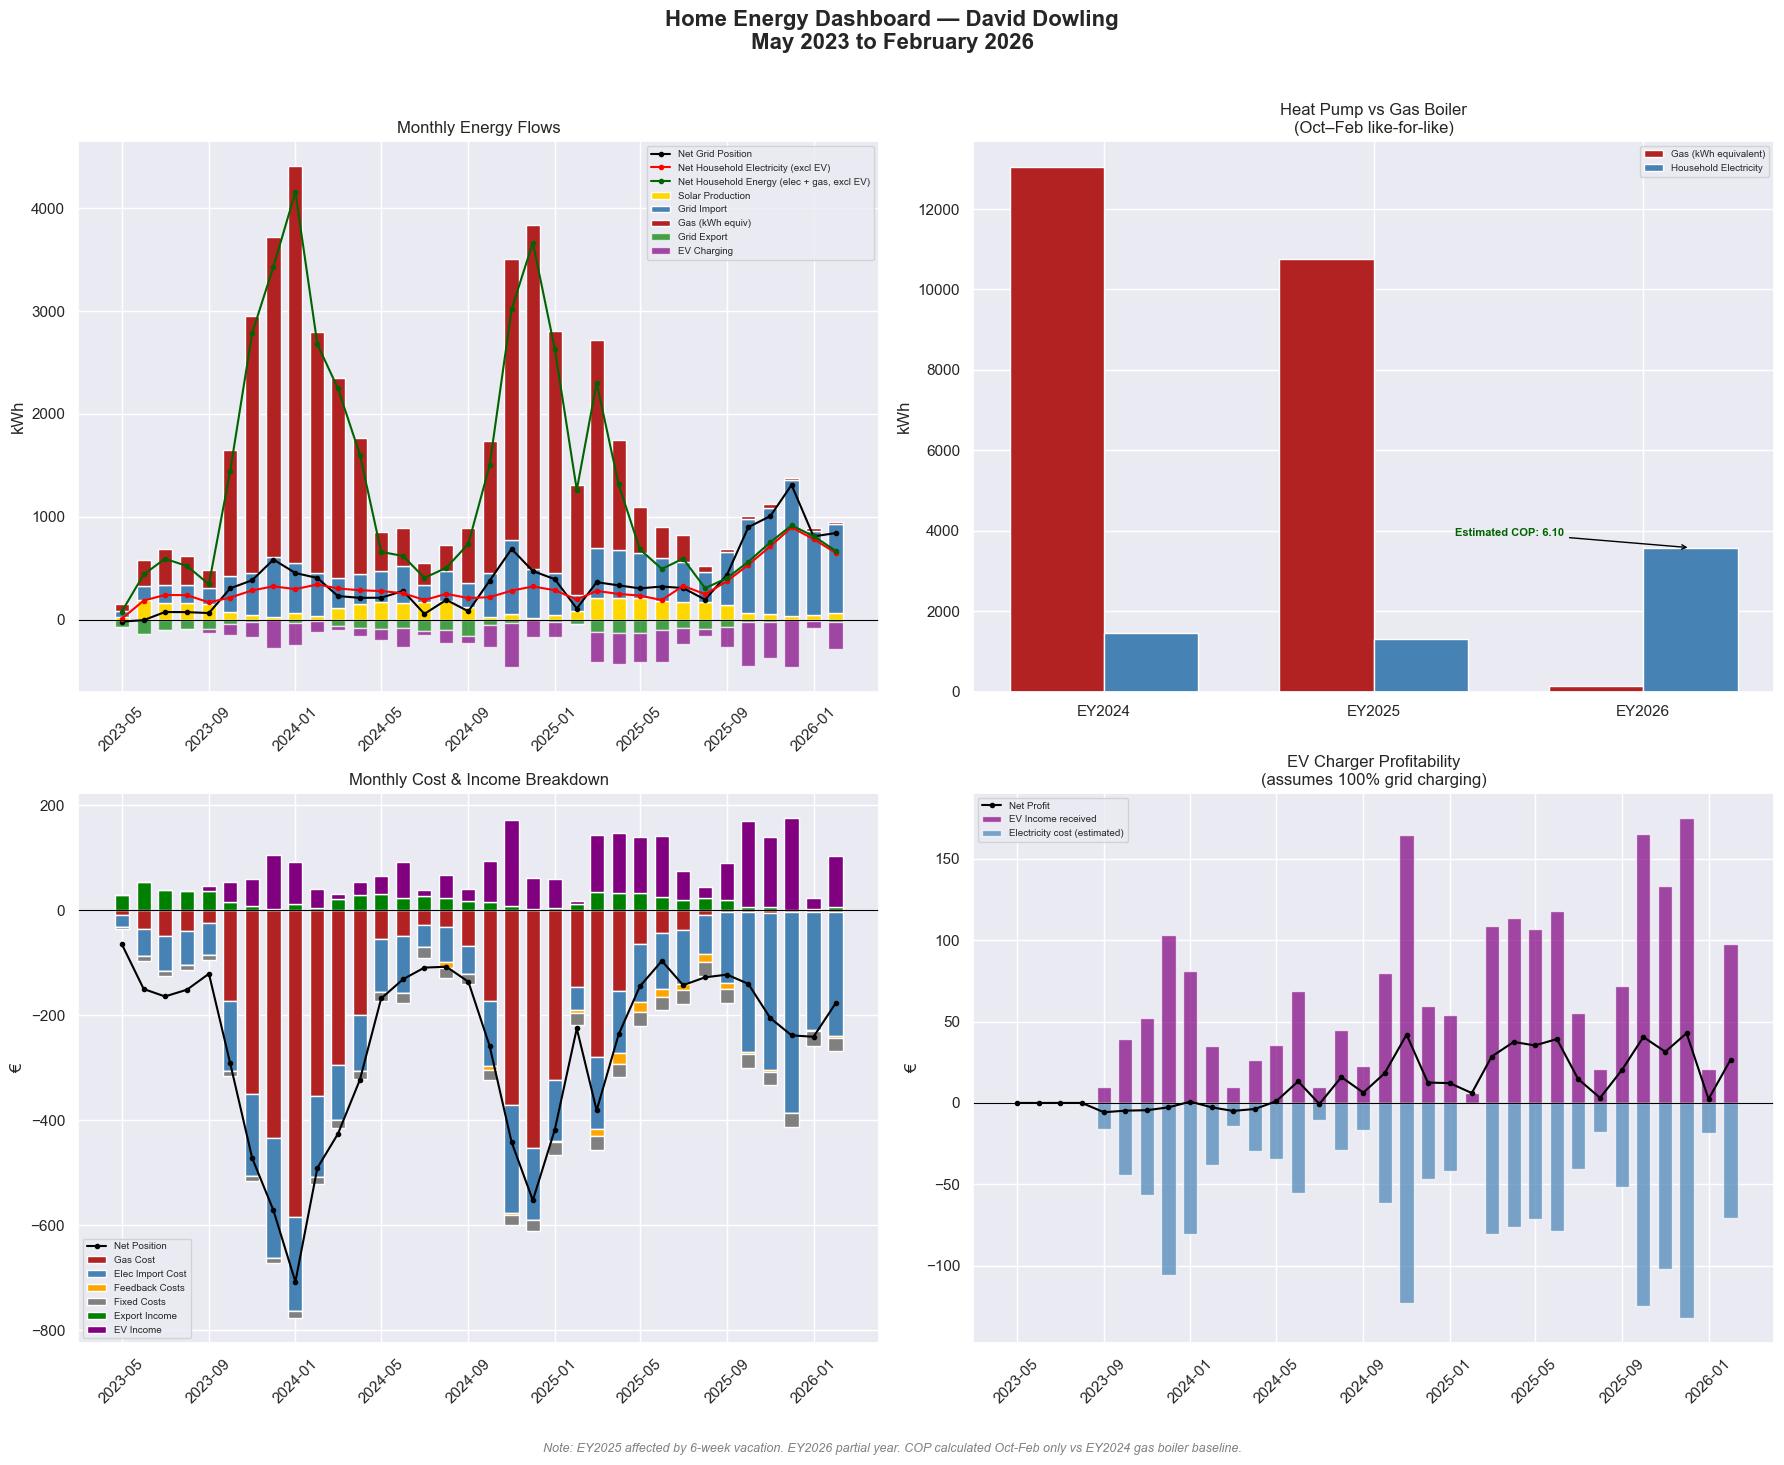

Dashboard saved ✓


In [5]:
# ── HOME ENERGY DASHBOARD ─────────────────────────────

# Calculate heating season summary first
heating_months = df[df.index.month.isin([10, 11, 12, 1, 2])]
heating_summary = heating_months.groupby("Energy Year").agg(
    Gas_kWh=("Gas kWh", "sum"),
    Household_Elec=("Household Elec", "sum"),
).reset_index()

heating_summary["Gas_Delta"] = heating_summary["Gas_kWh"] - heating_summary["Gas_kWh"].iloc[0]
heating_summary["Elec_Delta"] = heating_summary["Household_Elec"] - heating_summary["Household_Elec"].iloc[0]

ey2026 = heating_summary[heating_summary["Energy Year"] == "EY2026"].iloc[0]
cop_estimate = abs(ey2026["Gas_Delta"]) / ey2026["Elec_Delta"]

# ── FIGURE SETUP ──────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Home Energy Dashboard — David Dowling\nMay 2023 to February 2026",
             fontsize=16, fontweight="bold", y=1.01)

# ── CHART 1: Monthly Energy Flows (top left) ──────────
ax1 = fig.add_subplot(2, 2, 1)
ax1.bar(df.index, df["Solar Production"], width=20,
        color="gold", label="Solar Production")
ax1.bar(df.index, df["Elec Import"], width=20,
        color="steelblue", label="Grid Import",
        bottom=df["Solar Production"])
ax1.bar(df.index, df["Gas kWh"], width=20,
        color="firebrick", label="Gas (kWh equiv)",
        bottom=df["Solar Production"] + df["Elec Import"])
ax1.bar(df.index, df["Elec Export"], width=20,
        color="green", alpha=0.7, label="Grid Export")
ax1.bar(df.index, df["EV Charger Use"], width=20,
        color="purple", alpha=0.7, label="EV Charging",
        bottom=df["Elec Export"])
ax1.plot(df.index, df["Net Grid Use"],
         color="black", linewidth=1.5, marker="o", markersize=3,
         label="Net Grid Position")
ax1.plot(df.index, df["Household Elec"],
         color="red", linewidth=1.5, marker="o", markersize=3,
         label="Net Household Electricity (excl EV)")
ax1.plot(df.index, df["Household Elec"] + df["Gas kWh"],
         color="darkgreen", linewidth=1.5, marker="o", markersize=3,
         label="Net Household Energy (elec + gas, excl EV)")
ax1.axhline(y=0, color="black", linewidth=0.8)
ax1.set_title("Monthly Energy Flows")
ax1.set_ylabel("kWh")
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
ax1.legend(fontsize=7)

# ── CHART 2: Heat Pump vs Gas Boiler (top right) ──────
ax2 = fig.add_subplot(2, 2, 2)
x = np.arange(len(heating_summary))
width = 0.35
ax2.bar(x - width/2, heating_summary["Gas_kWh"], width,
        color="firebrick", label="Gas (kWh equivalent)")
ax2.bar(x + width/2, heating_summary["Household_Elec"], width,
        color="steelblue", label="Household Electricity")
ax2.set_title("Heat Pump vs Gas Boiler\n(Oct–Feb like-for-like)")
ax2.set_ylabel("kWh")
ax2.set_xticks(x)
ax2.set_xticklabels(heating_summary["Energy Year"])
ax2.legend(fontsize=7)
ax2.annotate(f"Estimated COP: {cop_estimate:.2f}",
             xy=(2 + width/2, heating_summary["Household_Elec"].iloc[2]),
             xytext=(1.3, heating_summary["Household_Elec"].iloc[2] + 300),
             arrowprops=dict(arrowstyle="->", color="black"),
             fontsize=8, color="darkgreen", fontweight="bold")

# ── CHART 3: Monthly Cost Breakdown (bottom left) ─────
ax3 = fig.add_subplot(2, 2, 3)
ax3.bar(df.index, df["Gas Cost"] * -1, width=20,
        color="firebrick", label="Gas Cost")
ax3.bar(df.index, df["Elec Import Cost"] * -1, width=20,
        color="steelblue", label="Elec Import Cost",
        bottom=df["Gas Cost"] * -1)
ax3.bar(df.index, df["Feedback Costs"] * -1, width=20,
        color="orange", label="Feedback Costs",
        bottom=(df["Gas Cost"] + df["Elec Import Cost"]) * -1)
ax3.bar(df.index, df["Fixed Costs"] * -1, width=20,
        color="grey", label="Fixed Costs",
        bottom=(df["Gas Cost"] + df["Elec Import Cost"] + df["Feedback Costs"]) * -1)
ax3.bar(df.index, df["Export Income"].abs(), width=20,
        color="green", label="Export Income")
ax3.bar(df.index, df["EV Charger Income"].abs(), width=20,
        color="purple", label="EV Income",
        bottom=df["Export Income"].abs())
ax3.plot(df.index, df["Net Position"],
         color="black", linewidth=1.5, marker="o", markersize=3,
         label="Net Position")
ax3.axhline(y=0, color="black", linewidth=0.8)
ax3.set_title("Monthly Cost & Income Breakdown")
ax3.set_ylabel("€")
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)
ax3.legend(fontsize=7, loc="lower left")

# ── CHART 4: EV Profitability (bottom right) ──────────
ax4 = fig.add_subplot(2, 2, 4)
ax4.bar(df.index, df["EV Charger Income"].abs(), width=20,
        color="purple", alpha=0.7, label="EV Income received")
ax4.bar(df.index, df["EV Electricity Cost"] * -1, width=20,
        color="steelblue", alpha=0.7, label="Electricity cost (estimated)")
ax4.plot(df.index, df["EV Net Profit"],
         color="black", linewidth=1.5, marker="o", markersize=3,
         label="Net Profit")
ax4.axhline(y=0, color="black", linewidth=0.8)
ax4.set_title("EV Charger Profitability\n(assumes 100% grid charging)")
ax4.set_ylabel("€")
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)
ax4.legend(fontsize=7)

fig.text(0.5, -0.02,
         "Note: EY2025 affected by 6-week vacation. EY2026 partial year. COP calculated Oct-Feb only vs EY2024 gas boiler baseline.",
         ha="center", fontsize=9, style="italic", color="grey")
plt.tight_layout()
plt.savefig("home_energy_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved ✓")

In [6]:
# Check HDD data availability
print("── Heating Degree Days Data ──────────────")
print(df[["Heating Degree Days", "Energy Year"]].to_string())

── Heating Degree Days Data ──────────────
            Heating Degree Days Energy Year
Date                                       
2023-05-01               132.67      EY2023
2023-06-01                16.93      EY2023
2023-07-01                 5.49      EY2024
2023-08-01                 8.28      EY2024
2023-09-01                17.60      EY2024
2023-10-01               136.48      EY2024
2023-11-01               304.05      EY2024
2023-12-01               356.78      EY2024
2024-01-01               441.22      EY2024
2024-02-01               289.98      EY2024
2024-03-01               282.14      EY2024
2024-04-01               208.47      EY2024
2024-05-01                52.37      EY2024
2024-06-01                62.04      EY2024
2024-07-01                 8.86      EY2025
2024-08-01                 0.00      EY2025
2024-09-01                64.29      EY2025
2024-10-01               165.87      EY2025
2024-11-01               323.44      EY2025
2024-12-01               375.06  

In [7]:
# Load KNMI raw data
knmi_raw = pd.read_csv("etmgeg_260.txt", skiprows=50, header=0)
print(knmi_raw.head(10).to_string())
print(f"\nShape: {knmi_raw.shape}")
print(f"\nColumns: {knmi_raw.columns.tolist()}")

   # STN  YYYYMMDD  DDVEC  FHVEC     FG    FHX   FHXH    FHN   FHNH    FXX   FXXH     TG     TN    TNH     TX    TXH   T10N  T10NH     SQ     SP      Q     DR     RH    RHX   RHXH     PG     PX    PXH     PN    PNH    VVN   VVNH    VVX   VVXH     NG     UG     UX    UXH     UN    UNH   EV24
0    260  19010101                                                                   -50    -68           -24                          28     36                                                                                                              66                                   
1    260  19010102                                                                   -22    -38           -16                           0      0                                                                                                              86                                   
2    260  19010103                                                                   -29    -79            -7               

C:\Users\David\AppData\Local\Temp\ipykernel_27512\4030283712.py:2: DtypeWarning: Columns (0: DDVEC, 1: FHVEC, 2:    FG, 3:   FHX, 4:  FHXH, 5:   FHN, 6:  FHNH, 7:   TNH, 8:   TXH, 9:  T10N, 10:    SQ, 11:    SP, 12:     Q, 13:    DR, 14:    RH, 15:   RHX, 16:    PG, 17:    PX, 18:    PN, 19:   VVN, 20:    UG, 21:    UX, 22:   UXH, 23:    UN, 24:   UNH, 25:  EV24) have mixed types. Specify dtype option on import or set low_memory=False.
  knmi_raw = pd.read_csv("etmgeg_260.txt", skiprows=50, header=0)


In [8]:
# Clean column names - strip whitespace
knmi_raw.columns = knmi_raw.columns.str.strip()

# Convert date to datetime
knmi_raw["YYYYMMDD"] = pd.to_datetime(knmi_raw["YYYYMMDD"], format="%Y%m%d")

# Filter to May 2023 onwards
knmi = knmi_raw[knmi_raw["YYYYMMDD"] >= "2023-05-01"].copy()
knmi = knmi.reset_index(drop=True)

# Keep only the columns we need
knmi = knmi[["YYYYMMDD", "TG", "TN", "TX", "Q", "FG", "DR", "RH", "SQ", "UG", "NG"]]

# KNMI stores temperatures as °C × 10 — convert to °C
knmi["TG"] = knmi["TG"] / 10
knmi["TN"] = knmi["TN"] / 10
knmi["TX"] = knmi["TX"] / 10

# KNMI stores radiation as J/cm² — convert to kWh/m²
knmi["Q"] = knmi["Q"] / 10000 * 2.778

# Wind speed stored as 0.1 m/s — convert to m/s
knmi["FG"] = knmi["FG"] / 10

# Rename columns to meaningful names
knmi = knmi.rename(columns={
    "YYYYMMDD": "Date",
    "TG": "Temp_Mean",
    "TN": "Temp_Min",
    "TX": "Temp_Max",
    "Q": "Solar_Irradiance",
    "FG": "Wind_Speed",
    "DR": "Precip_Duration",
    "RH": "Precip_Amount",
    "SQ": "Sunshine_Hours",
    "UG": "Humidity",
    "NG": "Cloud_Cover"
})

print(f"Shape: {knmi.shape}")
print(f"Date range: {knmi['Date'].min()} to {knmi['Date'].max()}")
print(knmi.head(10).to_string())

Shape: (1053, 11)
Date range: 2023-05-01 00:00:00 to 2026-03-18 00:00:00
        Date  Temp_Mean  Temp_Min  Temp_Max Solar_Irradiance Wind_Speed Precip_Duration Precip_Amount Sunshine_Hours Humidity Cloud_Cover
0 2023-05-01       11.8       6.3      17.0         0.346694        2.0               7             1             45       74           7
1 2023-05-02        9.2       3.3      12.8         0.607826        3.3               0            -1             88       65           5
2 2023-05-03        9.3       0.6      15.6         0.712279        3.1               0             0            130       64           7
3 2023-05-04       14.9       5.9      22.1         0.654497        3.9               0             0            121       56           8
4 2023-05-05       13.8       9.9      18.8         0.315025        2.0              46           106             67       85           6
5 2023-05-06       14.8       8.8      20.6         0.500873        1.9              10            

In [9]:
# Calculate Heating Degree Days (HDD) and Cooling Degree Days (CDD)
# Dutch standard base temperature: 18°C
BASE_TEMP = 18.0

# HDD = degrees below base temperature (heating needed)
# CDD = degrees above base temperature (cooling needed)
knmi["HDD"] = (BASE_TEMP - knmi["Temp_Mean"]).clip(lower=0)
knmi["CDD"] = (knmi["Temp_Mean"] - BASE_TEMP).clip(lower=0)

# Verify
print(f"Base temperature: {BASE_TEMP}°C")
print(f"\nSample HDD/CDD values:")
print(knmi[["Date", "Temp_Mean", "HDD", "CDD"]].head(20).to_string())
print(f"\nAnnual HDD summary:")
knmi["Year"] = knmi["Date"].dt.year
print(knmi.groupby("Year")["HDD"].sum())

Base temperature: 18.0°C

Sample HDD/CDD values:
         Date  Temp_Mean  HDD  CDD
0  2023-05-01       11.8  6.2  0.0
1  2023-05-02        9.2  8.8  0.0
2  2023-05-03        9.3  8.7  0.0
3  2023-05-04       14.9  3.1  0.0
4  2023-05-05       13.8  4.2  0.0
5  2023-05-06       14.8  3.2  0.0
6  2023-05-07       15.2  2.8  0.0
7  2023-05-08       14.8  3.2  0.0
8  2023-05-09       13.7  4.3  0.0
9  2023-05-10       13.0  5.0  0.0
10 2023-05-11       13.2  4.8  0.0
11 2023-05-12       15.5  2.5  0.0
12 2023-05-13       16.4  1.6  0.0
13 2023-05-14       14.6  3.4  0.0
14 2023-05-15       11.3  6.7  0.0
15 2023-05-16       10.7  7.3  0.0
16 2023-05-17       10.5  7.5  0.0
17 2023-05-18       10.2  7.8  0.0
18 2023-05-19       13.8  4.2  0.0
19 2023-05-20       15.9  2.1  0.0

Annual HDD summary:
Year
2023    1064.9
2024    2396.5
2025    2528.4
2026     988.6
Name: HDD, dtype: float64


In [10]:
# Check data types
print(knmi.dtypes)
print()
# Check for any non-numeric values
for col in ["HDD", "CDD", "Temp_Mean", "Temp_Min", "Temp_Max", 
            "Solar_Irradiance", "Sunshine_Hours", "Wind_Speed", 
            "Humidity", "Cloud_Cover", "Precip_Amount"]:
    non_numeric = knmi[pd.to_numeric(knmi[col], errors='coerce').isna() & knmi[col].notna()]
    if len(non_numeric) > 0:
        print(f"{col}: {len(non_numeric)} non-numeric values")
        print(non_numeric[["Date", col]].head(3))

Date                datetime64[us]
Temp_Mean                  float64
Temp_Min                   float64
Temp_Max                   float64
Solar_Irradiance            object
Wind_Speed                  object
Precip_Duration             object
Precip_Amount               object
Sunshine_Hours              object
Humidity                    object
Cloud_Cover                    str
HDD                        float64
CDD                        float64
Year                         int32
dtype: object

Cloud_Cover: 4 non-numeric values
          Date Cloud_Cover
866 2025-09-13            
867 2025-09-14            
868 2025-09-15            


In [11]:
# Convert Cloud_Cover to numeric, replacing any non-numeric values with NaN
knmi["Cloud_Cover"] = pd.to_numeric(knmi["Cloud_Cover"], errors='coerce')

# Check how many NaN values we now have
print(f"Cloud_Cover NaN count: {knmi['Cloud_Cover'].isna().sum()}")
print(knmi["Cloud_Cover"].describe())

Cloud_Cover NaN count: 4
count    1049.000000
mean        6.158246
std         2.117208
min         0.000000
25%         5.000000
50%         7.000000
75%         8.000000
max         8.000000
Name: Cloud_Cover, dtype: float64


In [12]:
# Fill the 4 missing cloud cover values with forward fill
knmi["Cloud_Cover"] = knmi["Cloud_Cover"].ffill()
print(f"Cloud_Cover NaN count after fill: {knmi['Cloud_Cover'].isna().sum()}")

Cloud_Cover NaN count after fill: 0


In [13]:
# Aggregate daily weather data to monthly
knmi["Month"] = knmi["Date"].dt.to_period("M")

knmi_monthly = knmi.groupby("Month").agg(
    HDD=("HDD", "sum"),
    CDD=("CDD", "sum"),
    Temp_Mean=("Temp_Mean", "mean"),
    Temp_Min=("Temp_Min", "min"),
    Temp_Max=("Temp_Max", "max"),
    Solar_Irradiance=("Solar_Irradiance", "sum"),
    Sunshine_Hours=("Sunshine_Hours", "sum"),
    Wind_Speed=("Wind_Speed", "mean"),
    Humidity=("Humidity", "mean"),
    Cloud_Cover=("Cloud_Cover", "mean"),
    Precip_Amount=("Precip_Amount", "sum")
).reset_index()

# Convert Period to datetime for merging
knmi_monthly["Date"] = knmi_monthly["Month"].dt.to_timestamp()
knmi_monthly = knmi_monthly.drop(columns=["Month"])

print(f"Shape: {knmi_monthly.shape}")
print(knmi_monthly.head(10).to_string())

Shape: (35, 12)
     HDD   CDD  Temp_Mean  Temp_Min  Temp_Max Solar_Irradiance Sunshine_Hours Wind_Speed   Humidity  Cloud_Cover Precip_Amount       Date
0  140.8   0.0  13.458065       0.6      24.3        17.310829           2681   3.148387  73.548387     5.387097           553 2023-05-01
1   21.9  63.7  19.393333       8.5      31.3        20.271344           3260   3.213333       62.1     3.833333           142 2023-06-01
2   24.8  28.5  18.119355       8.4      32.2        15.233163           2014   3.509677  74.064516     6.451613          1207 2023-07-01
3   35.1  22.3  17.587097       9.1      27.5          13.1955           1991   2.729032  81.064516     6.258065           958 2023-08-01
4   43.5  27.9  17.480000       7.3      31.1        10.395276           1989       2.47  81.533333     5.766667           523 2023-09-01
5  148.3   0.3  13.225806       4.6      23.6         4.892336           1007   3.470968  87.258065     7.161290          2195 2023-10-01
6  306.0   0.0   7

In [14]:
# Merge energy data with weather data
df_merged = df.merge(knmi_monthly, left_index=True, right_on="Date", how="left")
df_merged = df_merged.set_index("Date")

print(f"Shape: {df_merged.shape}")
print(f"Columns: {df_merged.columns.tolist()}")
print(f"\nMissing values after merge:")
print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

Shape: (34, 32)
Columns: ['Gas Use', 'Elec Use', 'Solar Production', 'Elec Import', 'Elec Export', 'EV Charger Use', 'Heating Degree Days', 'Gas Cost', 'Elec Import Cost', 'Export Income', 'Feedback Costs', 'Fixed Costs', 'EV Charger Income', 'Remarks', 'Gas kWh', 'Household Elec', 'Net Grid Use', 'EV Electricity Cost', 'EV Net Profit', 'Net Position', 'Energy Year', 'HDD', 'CDD', 'Temp_Mean', 'Temp_Min', 'Temp_Max', 'Solar_Irradiance', 'Sunshine_Hours', 'Wind_Speed', 'Humidity', 'Cloud_Cover', 'Precip_Amount']

Missing values after merge:
Heating Degree Days    14
Remarks                24
dtype: int64


In [15]:
# Drop old incomplete HDD column - replaced by KNMI calculated version
df_merged = df_merged.drop(columns=["Heating Degree Days"])

# Verify
print(f"Shape: {df_merged.shape}")
print(f"Missing values:")
print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

Shape: (34, 31)
Missing values:
Remarks    24
dtype: int64


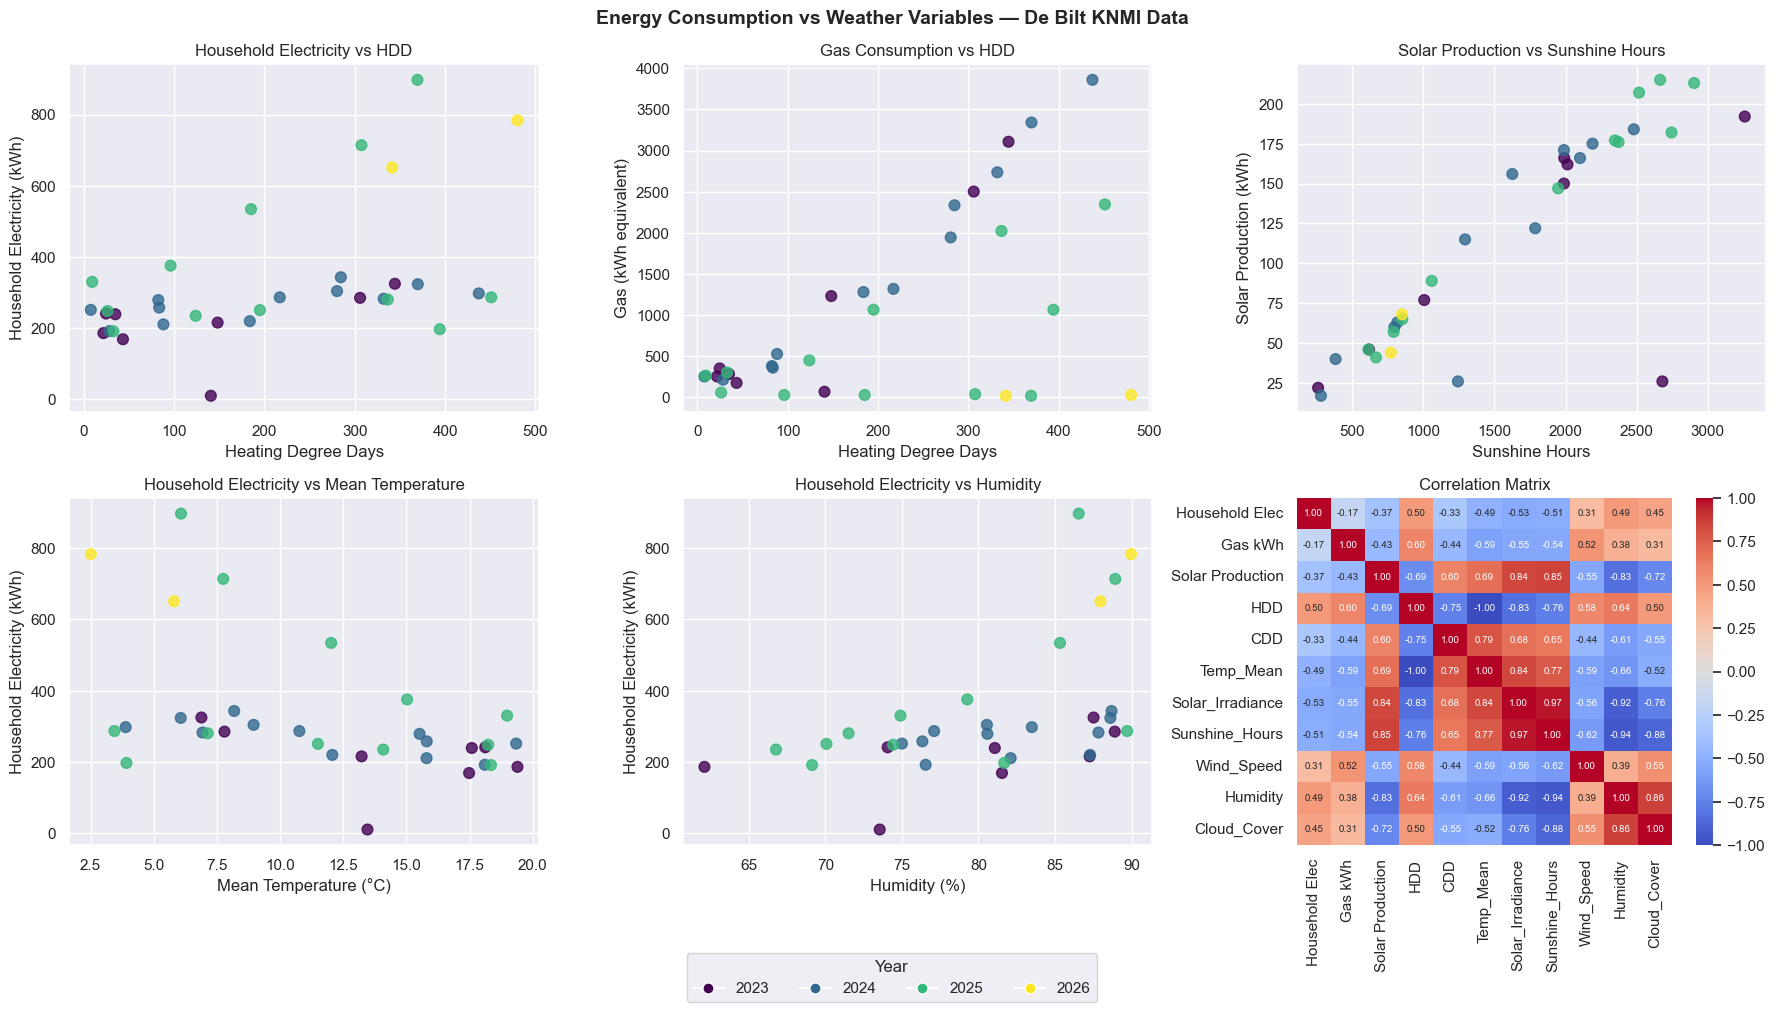

Correlation analysis saved ✓


In [16]:
# ── HDD CORRELATION ANALYSIS ──────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Energy Consumption vs Weather Variables — De Bilt KNMI Data",
             fontsize=14, fontweight="bold")

# Define heating months mask for some charts
heating_mask = df_merged.index.month.isin([10, 11, 12, 1, 2, 3, 4])

# 1 - Household Elec vs HDD
axes[0,0].scatter(df_merged["HDD"], df_merged["Household Elec"],
                  c=df_merged.index.year, cmap="viridis", s=60, alpha=0.8)
axes[0,0].set_title("Household Electricity vs HDD")
axes[0,0].set_xlabel("Heating Degree Days")
axes[0,0].set_ylabel("Household Electricity (kWh)")

# 2 - Gas kWh vs HDD
axes[0,1].scatter(df_merged["HDD"], df_merged["Gas kWh"],
                  c=df_merged.index.year, cmap="viridis", s=60, alpha=0.8)
axes[0,1].set_title("Gas Consumption vs HDD")
axes[0,1].set_xlabel("Heating Degree Days")
axes[0,1].set_ylabel("Gas (kWh equivalent)")

# 3 - Solar Production vs Sunshine Hours
axes[0,2].scatter(df_merged["Sunshine_Hours"], df_merged["Solar Production"],
                  c=df_merged.index.year, cmap="viridis", s=60, alpha=0.8)
axes[0,2].set_title("Solar Production vs Sunshine Hours")
axes[0,2].set_xlabel("Sunshine Hours")
axes[0,2].set_ylabel("Solar Production (kWh)")

# 4 - Household Elec vs Temperature
axes[1,0].scatter(df_merged["Temp_Mean"], df_merged["Household Elec"],
                  c=df_merged.index.year, cmap="viridis", s=60, alpha=0.8)
axes[1,0].set_title("Household Electricity vs Mean Temperature")
axes[1,0].set_xlabel("Mean Temperature (°C)")
axes[1,0].set_ylabel("Household Electricity (kWh)")

# 5 - Household Elec vs Humidity
axes[1,1].scatter(df_merged["Humidity"], df_merged["Household Elec"],
                  c=df_merged.index.year, cmap="viridis", s=60, alpha=0.8)
axes[1,1].set_title("Household Electricity vs Humidity")
axes[1,1].set_xlabel("Humidity (%)")
axes[1,1].set_ylabel("Household Electricity (kWh)")

# 6 - Correlation heatmap of all weather vs energy variables
corr_cols = ["Household Elec", "Gas kWh", "Solar Production",
             "HDD", "CDD", "Temp_Mean", "Solar_Irradiance",
             "Sunshine_Hours", "Wind_Speed", "Humidity", "Cloud_Cover"]
corr_matrix = df_merged[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, ax=axes[1,2], annot_kws={"size": 7})
axes[1,2].set_title("Correlation Matrix")

# Add colorbar legend for year colours
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Add discrete legend for years
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors

years = sorted(df_merged.index.year.unique())
norm = mcolors.Normalize(vmin=min(years), vmax=max(years))
cmap = plt.colormaps["viridis"]

legend_elements = [Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=cmap(norm(year)),
                          markersize=8, label=str(year))
                   for year in years]

fig.legend(handles=legend_elements, title="Year",
           loc="lower center", ncol=len(years),
           bbox_to_anchor=(0.5, -0.02), frameon=True)

plt.tight_layout()
plt.savefig("weather_energy_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Correlation analysis saved ✓")

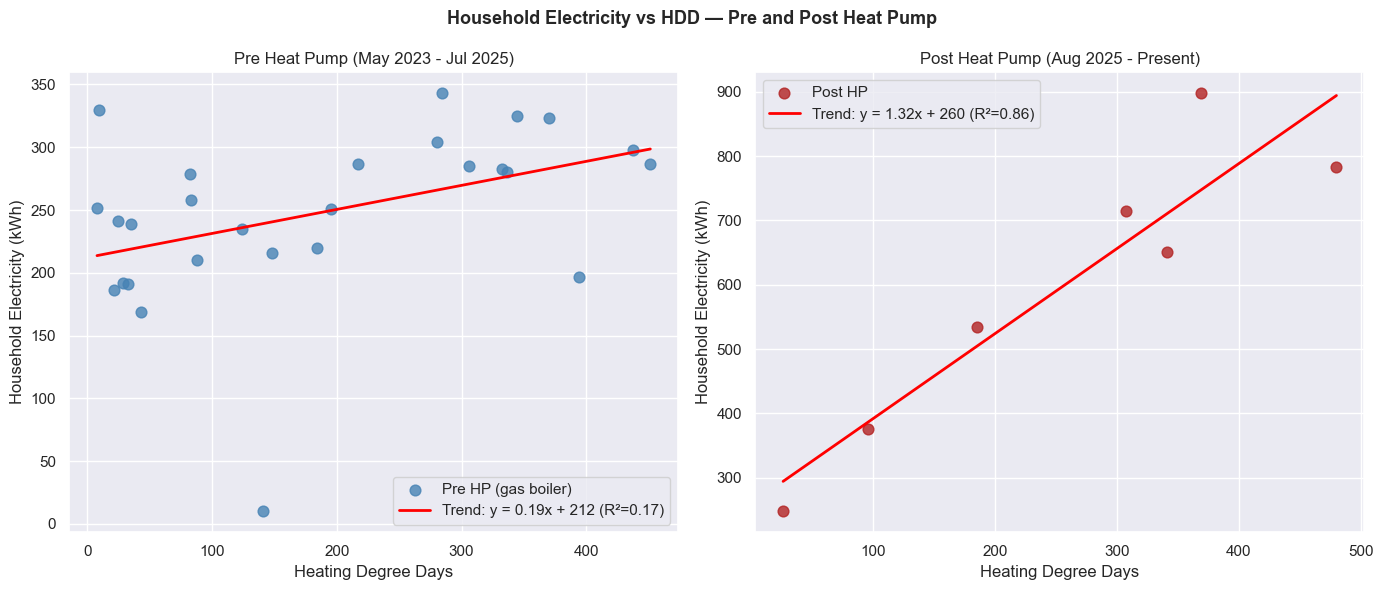

Pre HP:  0.192 kWh per HDD (R²=0.171)
Post HP: 1.321 kWh per HDD (R²=0.862)

Interpretation: Each additional HDD requires 1.32 kWh
extra electricity with HP vs 0.19 kWh pre-HP (gas was doing the heating)


In [17]:
from scipy import stats

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Household Electricity vs HDD — Pre and Post Heat Pump",
             fontsize=13, fontweight="bold")

# Split data into pre and post HP
pre_hp = df_merged[df_merged.index < "2025-08-01"]
post_hp = df_merged[df_merged.index >= "2025-08-01"]

# Left chart - Pre HP
ax1.scatter(pre_hp["HDD"], pre_hp["Household Elec"],
            color="steelblue", s=60, alpha=0.8, label="Pre HP (gas boiler)")

# Add trend line for pre HP
slope, intercept, r, p, se = stats.linregress(pre_hp["HDD"], pre_hp["Household Elec"])
x_line = np.linspace(pre_hp["HDD"].min(), pre_hp["HDD"].max(), 100)
ax1.plot(x_line, slope * x_line + intercept, color="red", linewidth=2,
         label=f"Trend: y = {slope:.2f}x + {intercept:.0f} (R²={r**2:.2f})")
ax1.set_title("Pre Heat Pump (May 2023 - Jul 2025)")
ax1.set_xlabel("Heating Degree Days")
ax1.set_ylabel("Household Electricity (kWh)")
ax1.legend()

# Right chart - Post HP
ax2.scatter(post_hp["HDD"], post_hp["Household Elec"],
            color="firebrick", s=60, alpha=0.8, label="Post HP")

# Add trend line for post HP
slope_hp, intercept_hp, r_hp, p_hp, se_hp = stats.linregress(
    post_hp["HDD"], post_hp["Household Elec"])
x_line_hp = np.linspace(post_hp["HDD"].min(), post_hp["HDD"].max(), 100)
ax2.plot(x_line_hp, slope_hp * x_line_hp + intercept_hp, color="red", linewidth=2,
         label=f"Trend: y = {slope_hp:.2f}x + {intercept_hp:.0f} (R²={r_hp**2:.2f})")
ax2.set_title("Post Heat Pump (Aug 2025 - Present)")
ax2.set_xlabel("Heating Degree Days")
ax2.set_ylabel("Household Electricity (kWh)")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Pre HP:  {slope:.3f} kWh per HDD (R²={r**2:.3f})")
print(f"Post HP: {slope_hp:.3f} kWh per HDD (R²={r_hp**2:.3f})")
print(f"\nInterpretation: Each additional HDD requires {slope_hp:.2f} kWh")
print(f"extra electricity with HP vs {slope:.2f} kWh pre-HP (gas was doing the heating)")

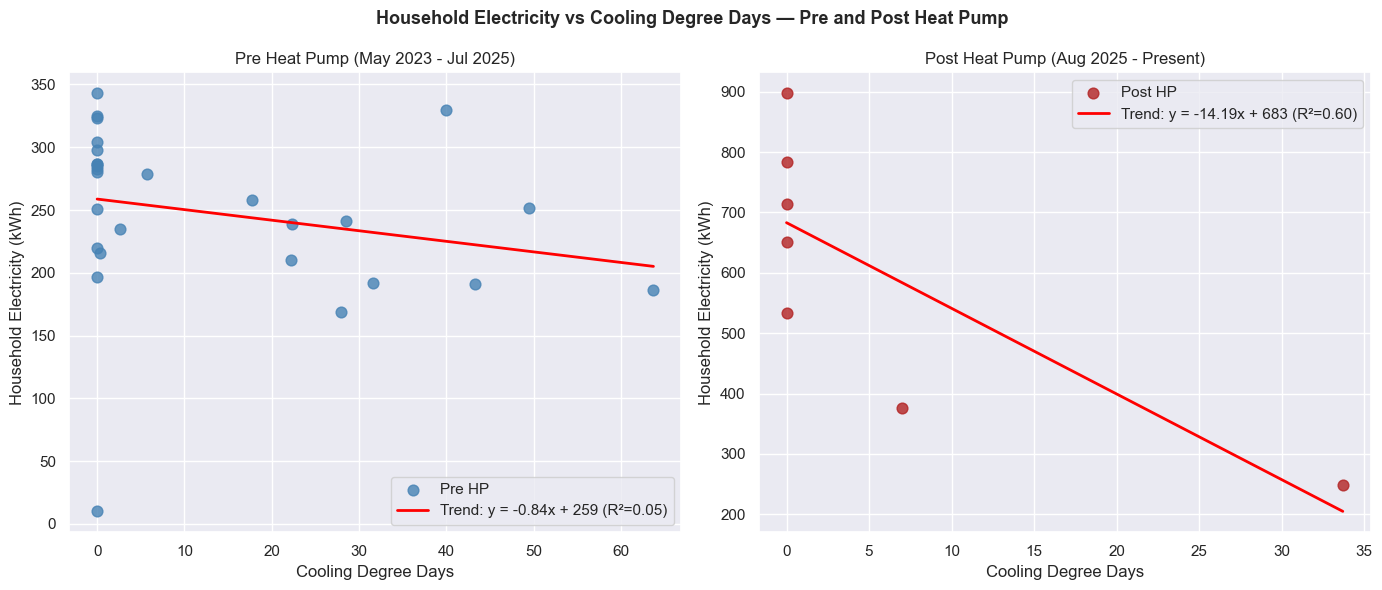

Pre HP:  slope=-0.842 kWh/CDD  R²=0.055
Post HP: slope=-14.193 kWh/CDD  R²=0.604


In [18]:
# ── CDD CORRELATION ANALYSIS ──────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Household Electricity vs Cooling Degree Days — Pre and Post Heat Pump",
             fontsize=13, fontweight="bold")

# Split data into pre and post HP
pre_hp = df_merged[df_merged.index < "2025-08-01"]
post_hp = df_merged[df_merged.index >= "2025-08-01"]

# Left chart - Pre HP
ax1.scatter(pre_hp["CDD"], pre_hp["Household Elec"],
            color="steelblue", s=60, alpha=0.8, label="Pre HP")

# Add trend line for pre HP
slope, intercept, r, p, se = stats.linregress(pre_hp["CDD"], pre_hp["Household Elec"])
x_line = np.linspace(pre_hp["CDD"].min(), pre_hp["CDD"].max(), 100)
ax1.plot(x_line, slope * x_line + intercept, color="red", linewidth=2,
         label=f"Trend: y = {slope:.2f}x + {intercept:.0f} (R²={r**2:.2f})")
ax1.set_title("Pre Heat Pump (May 2023 - Jul 2025)")
ax1.set_xlabel("Cooling Degree Days")
ax1.set_ylabel("Household Electricity (kWh)")
ax1.legend()

# Right chart - Post HP
ax2.scatter(post_hp["CDD"], post_hp["Household Elec"],
            color="firebrick", s=60, alpha=0.8, label="Post HP")

# Add trend line for post HP
slope_hp, intercept_hp, r_hp, p_hp, se_hp = stats.linregress(
    post_hp["CDD"], post_hp["Household Elec"])
x_line_hp = np.linspace(post_hp["CDD"].min(), post_hp["CDD"].max(), 100)
ax2.plot(x_line_hp, slope_hp * x_line_hp + intercept_hp, color="red", linewidth=2,
         label=f"Trend: y = {slope_hp:.2f}x + {intercept_hp:.0f} (R²={r_hp**2:.2f})")
ax2.set_title("Post Heat Pump (Aug 2025 - Present)")
ax2.set_xlabel("Cooling Degree Days")
ax2.set_ylabel("Household Electricity (kWh)")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Pre HP:  slope={slope:.3f} kWh/CDD  R²={r**2:.3f}")
print(f"Post HP: slope={slope_hp:.3f} kWh/CDD  R²={r_hp**2:.3f}")

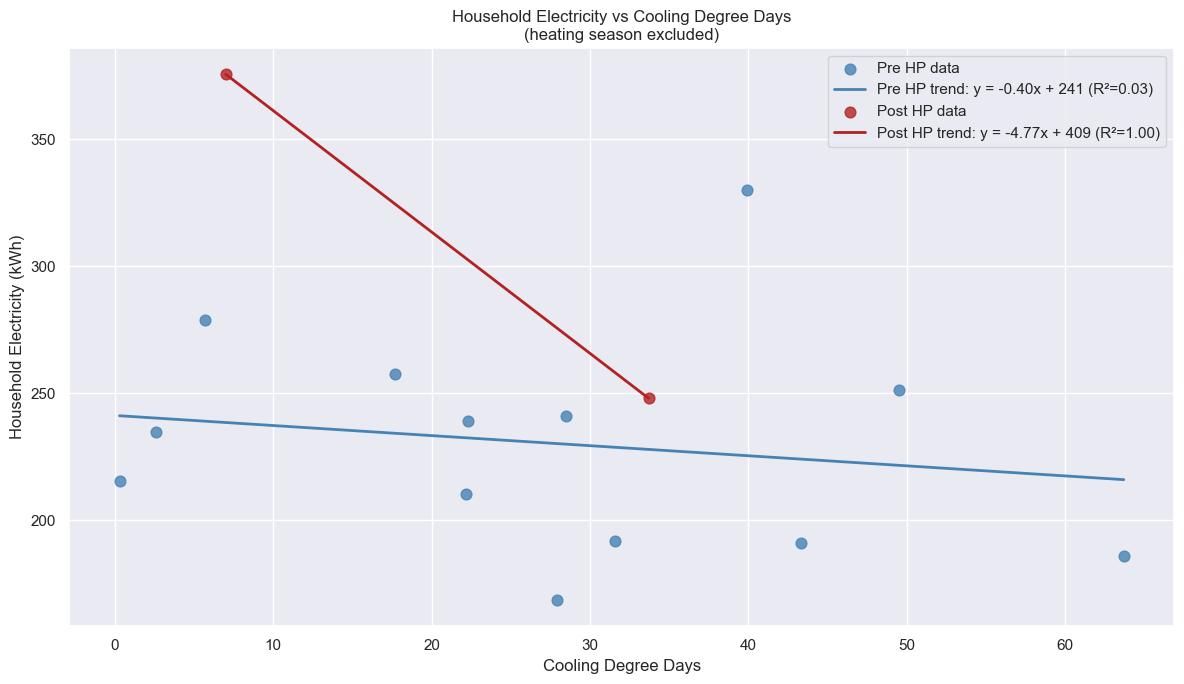

Pre HP cooling months: 13
Post HP cooling months: 2
Pre HP:  slope=-0.396 kWh/CDD  R²=0.029


In [19]:
# Filter to only months where CDD > 0 (genuine cooling months)
cdd_data = df_merged[df_merged["CDD"] > 0].copy()

# Split into pre and post HP
cdd_pre_hp = cdd_data[cdd_data.index < "2025-08-01"]
cdd_post_hp = cdd_data[cdd_data.index >= "2025-08-01"]

fig, ax = plt.subplots(figsize=(12, 7))

# Pre HP scatter and trend - blue
ax.scatter(cdd_pre_hp["CDD"], cdd_pre_hp["Household Elec"],
           color="steelblue", s=60, alpha=0.8, label="Pre HP data")

slope, intercept, r, p, se = stats.linregress(
    cdd_pre_hp["CDD"], cdd_pre_hp["Household Elec"])
x_line = np.linspace(cdd_data["CDD"].min(), cdd_data["CDD"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="steelblue", linewidth=2,
        label=f"Pre HP trend: y = {slope:.2f}x + {intercept:.0f} (R²={r**2:.2f})")

# Post HP scatter and trend - red
ax.scatter(cdd_post_hp["CDD"], cdd_post_hp["Household Elec"],
           color="firebrick", s=60, alpha=0.8, label="Post HP data")

if len(cdd_post_hp) >= 2:
    slope_hp, intercept_hp, r_hp, p_hp, se_hp = stats.linregress(
        cdd_post_hp["CDD"], cdd_post_hp["Household Elec"])
    x_line_hp = np.linspace(cdd_post_hp["CDD"].min(), cdd_post_hp["CDD"].max(), 100)
    ax.plot(x_line_hp, slope_hp * x_line_hp + intercept_hp, color="firebrick", linewidth=2,
            label=f"Post HP trend: y = {slope_hp:.2f}x + {intercept_hp:.0f} (R²={r_hp**2:.2f})")
else:
    print("Not enough post HP cooling data for trend line yet")

ax.set_title("Household Electricity vs Cooling Degree Days\n(heating season excluded)")
ax.set_xlabel("Cooling Degree Days")
ax.set_ylabel("Household Electricity (kWh)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pre HP cooling months: {len(cdd_pre_hp)}")
print(f"Post HP cooling months: {len(cdd_post_hp)}")
print(f"Pre HP:  slope={slope:.3f} kWh/CDD  R²={r**2:.3f}")

## CDD Analysis — Insufficient Data

Post heat pump cooling season data currently limited to 2 months (Aug-Sep 2025).
The passive cooling system (COP >20, pump only) was active during this period.

**Conclusion:** Cannot draw statistically meaningful conclusions from 2 data points.
Analysis to be revisited after summer 2026 when a full cooling season of data
will be available from both the billing data and the live Thermia API.

**Expected finding:** Small positive slope (pump electricity only) with moderate R²
once sufficient data is available.

In [20]:
# Load daily energy data
daily_raw = pd.read_excel("daily_energy.xlsx")

# Quick inspection
print(f"Shape: {daily_raw.shape}")
print(f"Date range: {daily_raw['Date'].min()} to {daily_raw['Date'].max()}")
print(f"\nMissing values:")
print(daily_raw.isnull().sum())
print(f"\nFirst 5 rows:")
daily_raw.head()

Shape: (121, 8)
Date range: 2025-12-01 00:00:00 to 2026-03-31 00:00:00

Missing values:
Date                 0
Elec_Import         12
Elec_Export         12
EV_Charger          84
EV Confidence       84
Vacation             0
Elec_Use            12
Solar_Production    12
dtype: int64

First 5 rows:


,Date,Elec_Import,Elec_Export,EV_Charger,EV Confidence,Vacation,Elec_Use,Solar_Production
0,2025-12-01,26.0,0.0,NaN,NaN,0,27.0,0.34
1,2025-12-02,31.0,0.0,NaN,NaN,0,31.0,0.33
2,2025-12-03,45.0,0.0,34.10,0.5,0,45.0,0.37
3,2025-12-04,61.0,0.0,17.48,0.5,0,62.0,2.90
4,2025-12-05,22.0,0.0,NaN,NaN,0,22.0,0.21


In [21]:
# ── DAILY DATA CLEANING & CALCULATIONS ───────────────

# Work on a copy
daily_df = daily_raw.copy()

# Step 1 - Set date as index
daily_df = daily_df.set_index("Date")

# Step 2 - Remove future dates with no data yet
daily_df = daily_df[daily_df["Elec_Import"].notna()]

# Step 3 - Rename EV Confidence column (remove space)
daily_df = daily_df.rename(columns={"EV Confidence": "EV_Confidence"})

# Step 4 - Calculate derived columns
# Household electricity excluding EV (only where EV confidence >= 0.75)
daily_df["EV_Charger_Clean"] = daily_df["EV_Charger"].where(
    daily_df["EV_Confidence"] >= 0.75, other=np.nan)
daily_df["Household_Elec"] = daily_df["Elec_Use"] - daily_df["EV_Charger_Clean"].fillna(0)

# Solar self consumption
daily_df["Solar_Self_Consumed"] = daily_df["Solar_Production"] - daily_df["Elec_Export"]
daily_df["Solar_Self_Consumed"] = daily_df["Solar_Self_Consumed"].clip(lower=0)

# Net grid position
daily_df["Net_Grid"] = daily_df["Elec_Import"] - daily_df["Elec_Export"]

print(f"Shape: {daily_df.shape}")
print(f"Date range: {daily_df.index.min().strftime('%d %b %Y')} to {daily_df.index.max().strftime('%d %b %Y')}")
print(f"\nMissing values:")
print(daily_df.isnull().sum()[daily_df.isnull().sum() > 0])
print(f"\nFirst 5 rows:")
daily_df.head()

Shape: (109, 11)
Date range: 01 Dec 2025 to 19 Mar 2026

Missing values:
EV_Charger          72
EV_Confidence       72
EV_Charger_Clean    83
dtype: int64

First 5 rows:


,Elec_Import,Elec_Export,EV_Charger,EV_Confidence,Vacation,Elec_Use,Solar_Production,EV_Charger_Clean,Household_Elec,Solar_Self_Consumed,Net_Grid
Date,,,,,,,,,,,
2025-12-01,26.0,0.0,NaN,NaN,0,27.0,0.34,NaN,27.0,0.34,26.0
2025-12-02,31.0,0.0,NaN,NaN,0,31.0,0.33,NaN,31.0,0.33,31.0
2025-12-03,45.0,0.0,34.10,0.5,0,45.0,0.37,NaN,45.0,0.37,45.0
2025-12-04,61.0,0.0,17.48,0.5,0,62.0,2.90,NaN,62.0,2.90,61.0
2025-12-05,22.0,0.0,NaN,NaN,0,22.0,0.21,NaN,22.0,0.21,22.0


In [22]:
# Merge daily energy with daily KNMI weather data
# knmi already has daily data — merge on date
daily_merged = daily_df.merge(
    knmi[["Date", "Temp_Mean", "HDD", "CDD", "Solar_Irradiance", 
          "Sunshine_Hours", "Wind_Speed", "Humidity", "Cloud_Cover"]],
    left_index=True, right_on="Date", how="left"
)
daily_merged = daily_merged.set_index("Date")

print(f"Shape: {daily_merged.shape}")
print(f"\nMissing values:")
print(daily_merged.isnull().sum()[daily_merged.isnull().sum() > 0])

Shape: (109, 19)

Missing values:
EV_Charger          72
EV_Confidence       72
EV_Charger_Clean    83
Temp_Mean            1
HDD                  1
CDD                  1
Solar_Irradiance     1
Sunshine_Hours       1
Wind_Speed           1
Humidity             1
Cloud_Cover          1
dtype: int64


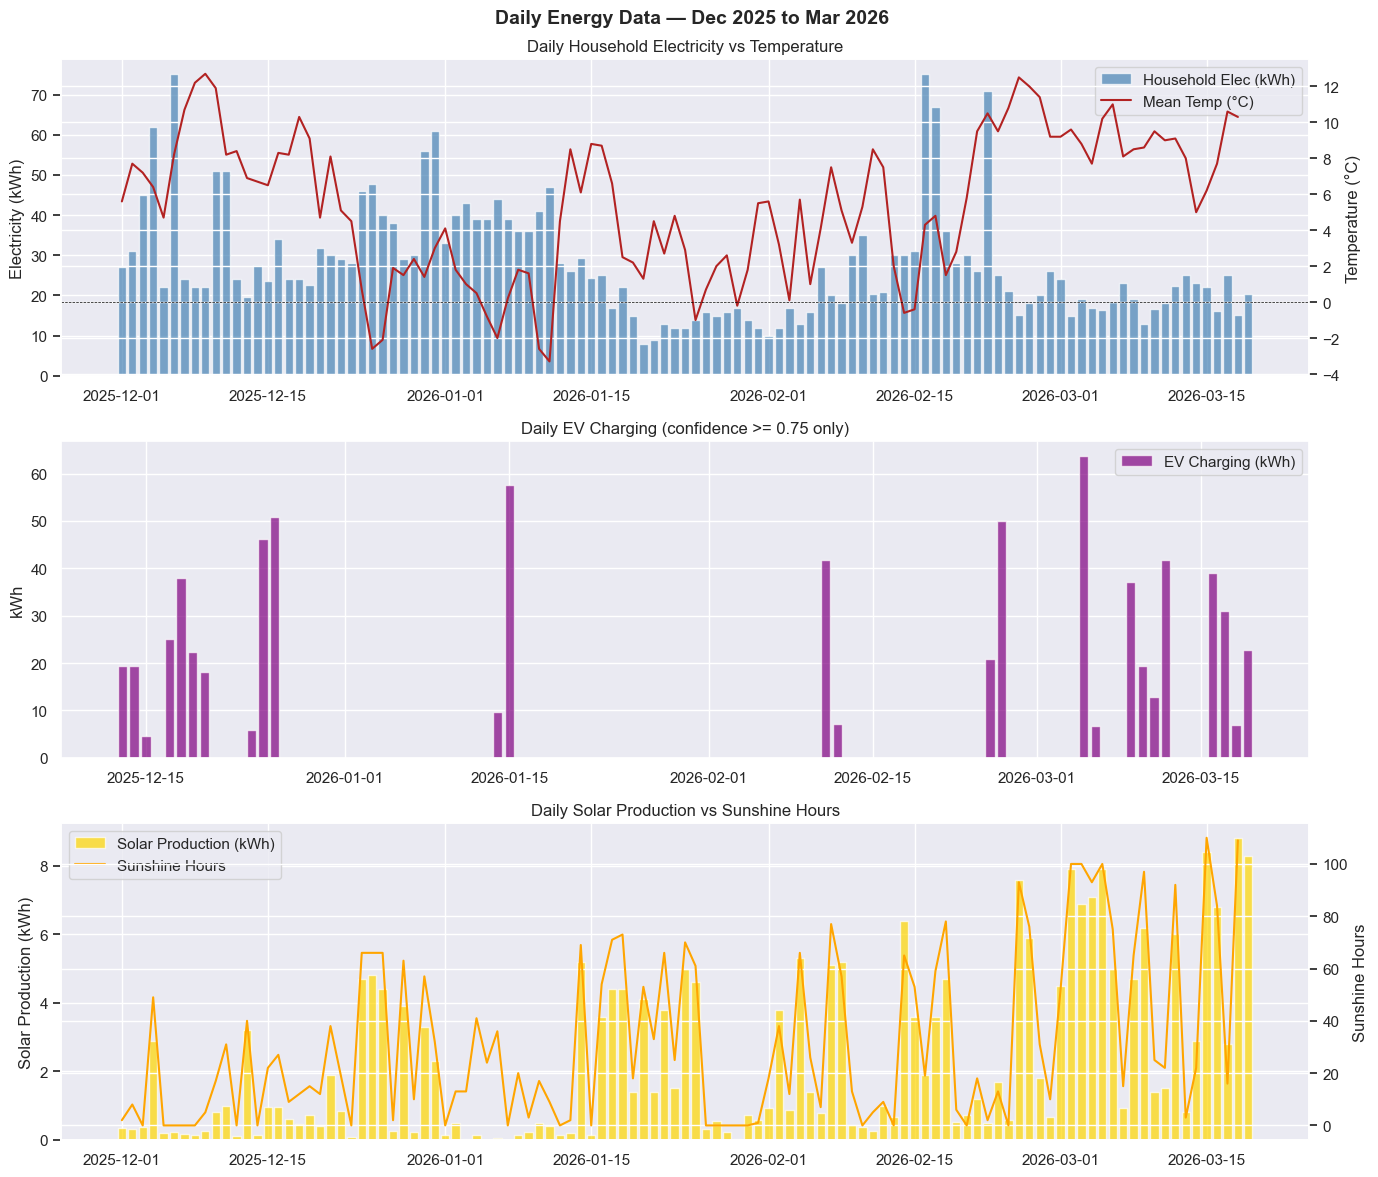

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Daily Energy Data — Dec 2025 to Mar 2026", 
             fontsize=14, fontweight="bold")

# Top - Household electricity and temperature
ax1 = axes[0]
ax1.bar(daily_merged.index, daily_merged["Household_Elec"], 
        width=0.8, color="steelblue", alpha=0.7, label="Household Elec (kWh)")
ax1_twin = ax1.twinx()
ax1_twin.plot(daily_merged.index, daily_merged["Temp_Mean"], 
              color="firebrick", linewidth=1.5, label="Mean Temp (°C)")
ax1_twin.axhline(y=0, color="black", linewidth=0.5, linestyle="--")
ax1.set_ylabel("Electricity (kWh)")
ax1_twin.set_ylabel("Temperature (°C)")
ax1.set_title("Daily Household Electricity vs Temperature")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

# Middle - EV charging
ax2 = axes[1]
ax2.bar(daily_merged.index, daily_merged["EV_Charger_Clean"],
        width=0.8, color="purple", alpha=0.7, label="EV Charging (kWh)")
ax2.set_ylabel("kWh")
ax2.set_title("Daily EV Charging (confidence >= 0.75 only)")
ax2.legend()

# Bottom - Solar production and sunshine hours
ax3 = axes[2]
ax3.bar(daily_merged.index, daily_merged["Solar_Production"],
        width=0.8, color="gold", alpha=0.7, label="Solar Production (kWh)")
ax3_twin = ax3.twinx()
ax3_twin.plot(daily_merged.index, daily_merged["Sunshine_Hours"],
              color="orange", linewidth=1.5, label="Sunshine Hours")
ax3.set_ylabel("Solar Production (kWh)")
ax3_twin.set_ylabel("Sunshine Hours")
ax3.set_title("Daily Solar Production vs Sunshine Hours")

lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Flag days where household electricity is unreliable
# (EV was charging but confidence < 0.75)
daily_merged["Household_Elec_Reliable"] = daily_merged["Household_Elec"].where(
    (daily_merged["EV_Confidence"] >= 0.75) | 
    (daily_merged["EV_Charger"].isna()),
    other=np.nan
)

# For unreliable days, still subtract best estimate EV if available
daily_merged["Household_Elec_Estimated"] = daily_merged["Elec_Use"].where(
    (daily_merged["EV_Confidence"] < 0.75) & 
    (daily_merged["EV_Charger"].notna()),
    other=np.nan
) - daily_merged["EV_Charger"].where(
    (daily_merged["EV_Confidence"] < 0.75) & 
    (daily_merged["EV_Charger"].notna()),
    other=np.nan
)

print(f"Reliable household days: {daily_merged['Household_Elec_Reliable'].notna().sum()}")
print(f"Estimated household days: {daily_merged['Household_Elec_Estimated'].notna().sum()}")
print(f"No EV days (exact): {daily_merged['EV_Charger'].isna().sum()}")

Reliable household days: 98
Estimated household days: 11
No EV days (exact): 72


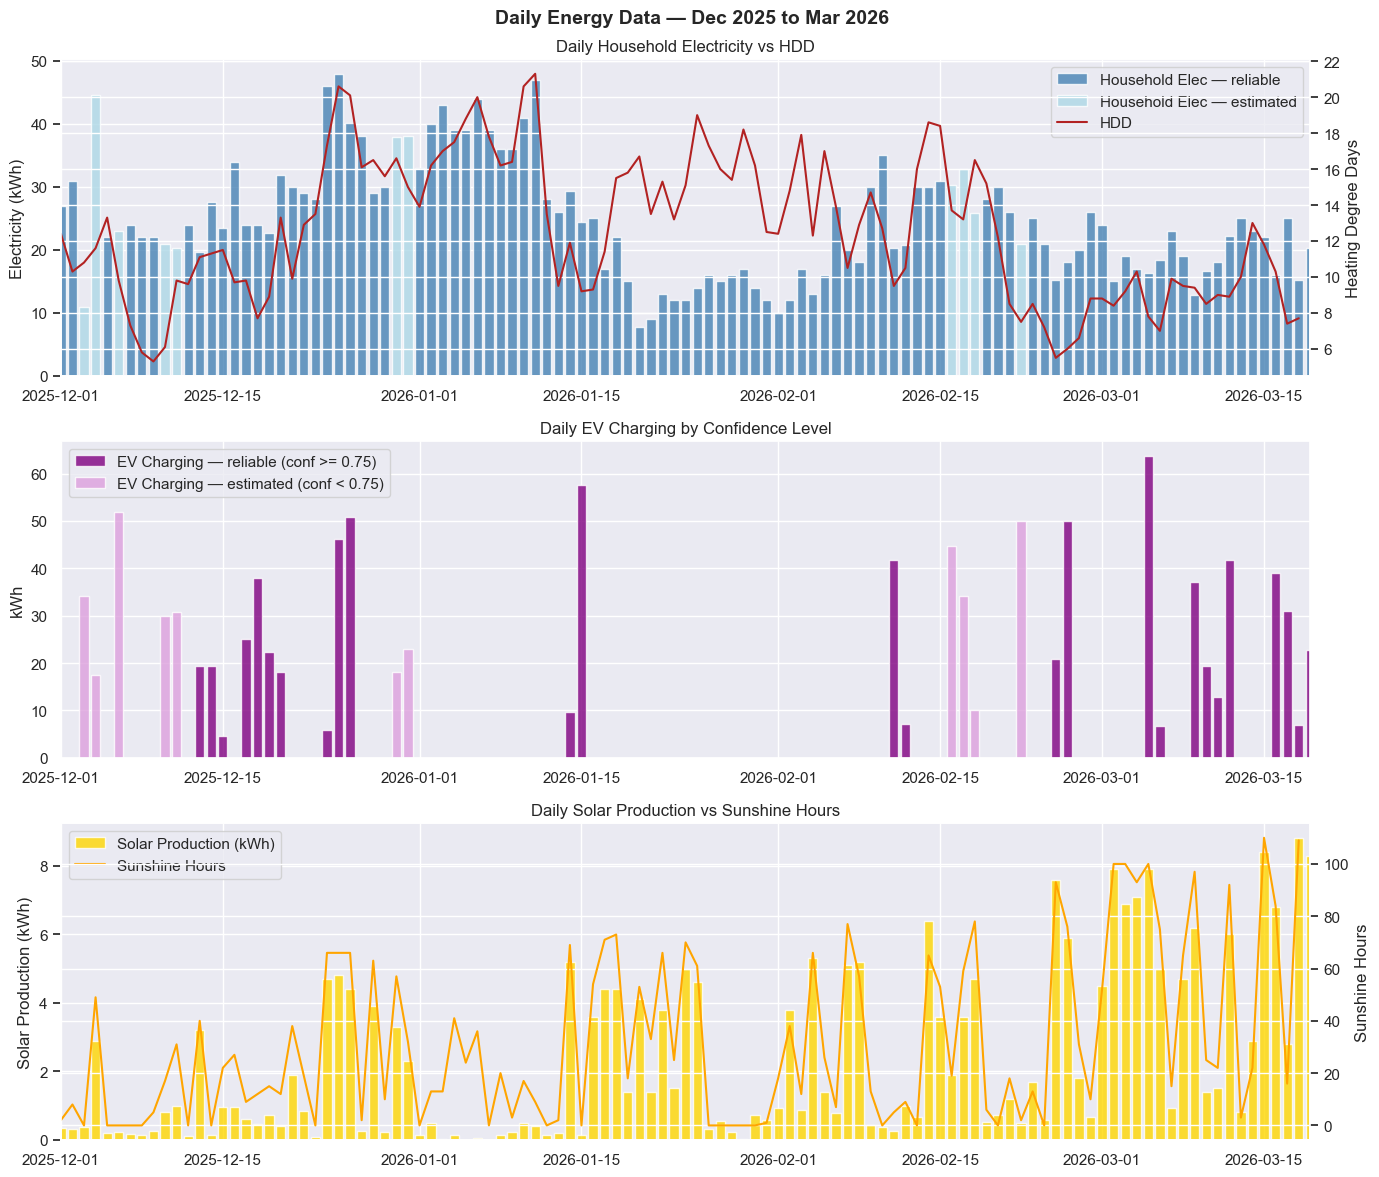

In [25]:
# Set consistent x-axis limits
x_min = daily_merged.index.min()
x_max = daily_merged.index.max()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Daily Energy Data — Dec 2025 to Mar 2026",
             fontsize=14, fontweight="bold")

# ── TOP: Household Electricity vs HDD ─────────────────
ax1 = axes[0]
ax1.bar(daily_merged.index, daily_merged["Household_Elec_Reliable"],
        width=0.8, color="steelblue", alpha=0.8, label="Household Elec — reliable")
ax1.bar(daily_merged.index, daily_merged["Household_Elec_Estimated"],
        width=0.8, color="lightblue", alpha=0.8, label="Household Elec — estimated")
ax1_twin = ax1.twinx()
ax1_twin.plot(daily_merged.index, daily_merged["HDD"],
              color="firebrick", linewidth=1.5, label="HDD")
ax1.set_ylabel("Electricity (kWh)")
ax1_twin.set_ylabel("Heating Degree Days")
ax1.set_title("Daily Household Electricity vs HDD")
ax1.set_xlim(x_min, x_max)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

# ── MIDDLE: EV Charging ────────────────────────────────
ax2 = axes[1]
ax2.bar(daily_merged.index, 
        daily_merged["EV_Charger_Clean"],
        width=0.8, color="purple", alpha=0.8, label="EV Charging — reliable (conf >= 0.75)")
ax2.bar(daily_merged.index,
        daily_merged["EV_Charger"].where(daily_merged["EV_Confidence"] < 0.75),
        width=0.8, color="plum", alpha=0.8, label="EV Charging — estimated (conf < 0.75)")
ax2.set_ylabel("kWh")
ax2.set_title("Daily EV Charging by Confidence Level")
ax2.set_xlim(x_min, x_max)
ax2.legend()

# ── BOTTOM: Solar vs Sunshine Hours ───────────────────
ax3 = axes[2]
ax3.bar(daily_merged.index, daily_merged["Solar_Production"],
        width=0.8, color="gold", alpha=0.8, label="Solar Production (kWh)")
ax3_twin = ax3.twinx()
ax3_twin.plot(daily_merged.index, daily_merged["Sunshine_Hours"],
              color="orange", linewidth=1.5, label="Sunshine Hours")
ax3.set_ylabel("Solar Production (kWh)")
ax3_twin.set_ylabel("Sunshine Hours")
ax3.set_title("Daily Solar Production vs Sunshine Hours")
ax3.set_xlim(x_min, x_max)
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

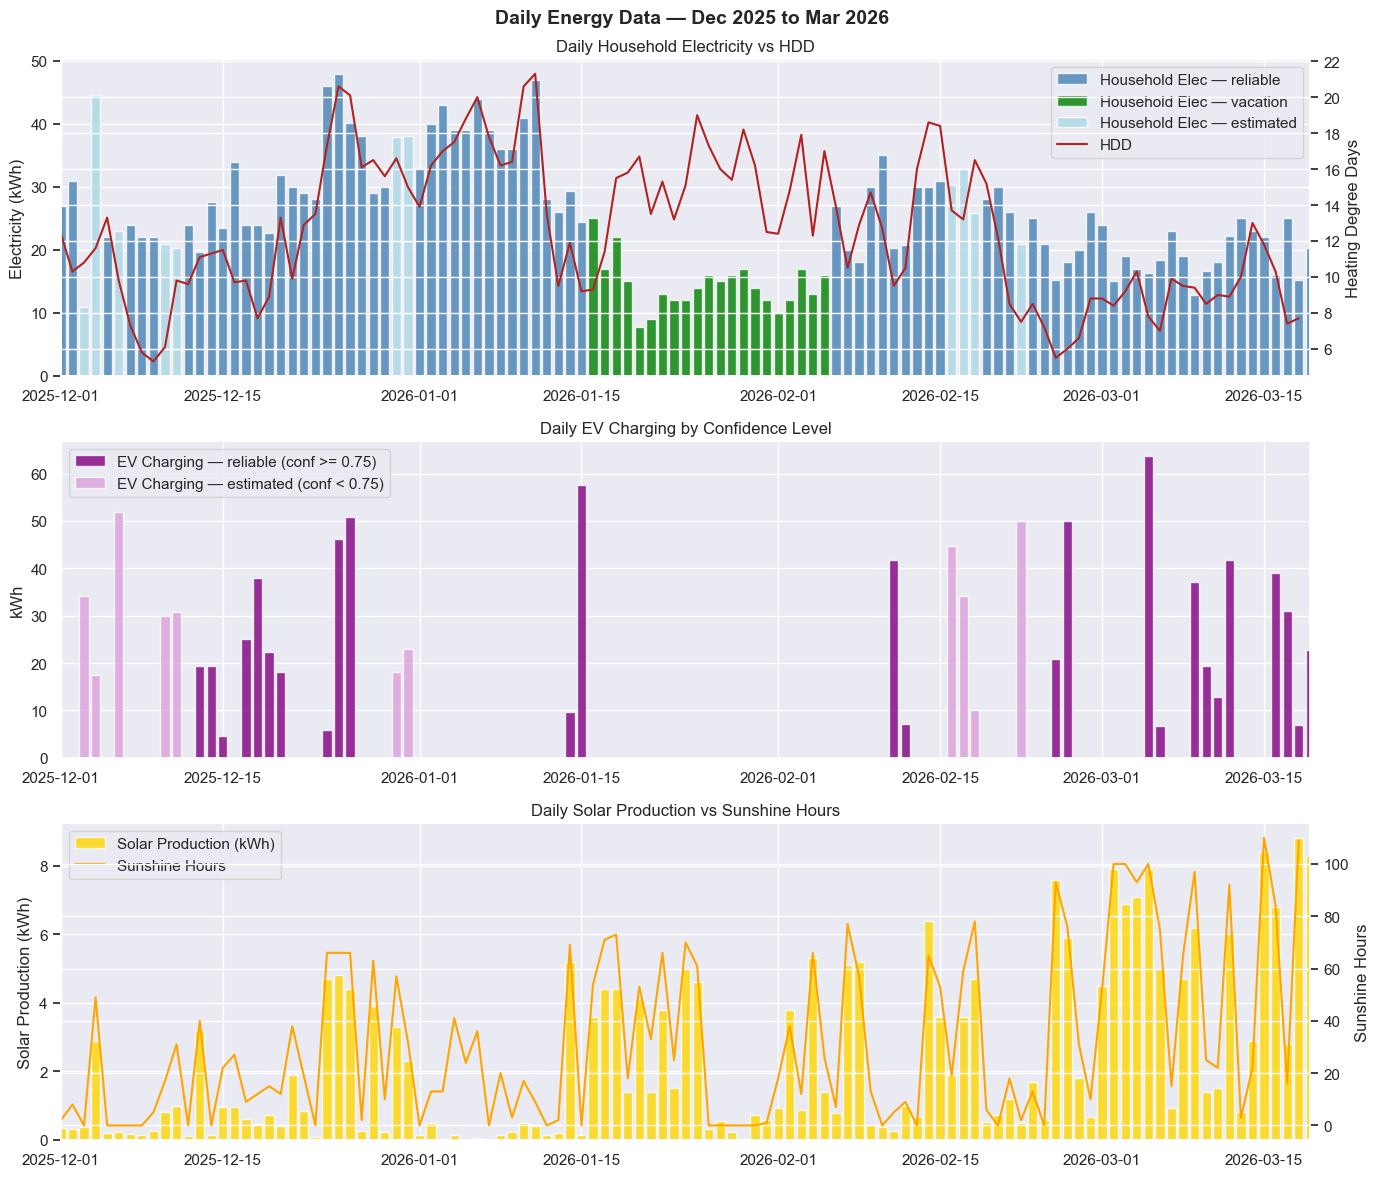

In [26]:
# Split household electricity into three categories
daily_merged["Household_Reliable_Normal"] = daily_merged["Household_Elec_Reliable"].where(
    daily_merged["Vacation"] == 0, other=np.nan)
daily_merged["Household_Reliable_Vacation"] = daily_merged["Household_Elec_Reliable"].where(
    daily_merged["Vacation"] == 1, other=np.nan)

# Rebuild top chart with vacation colouring
x_min = daily_merged.index.min()
x_max = daily_merged.index.max()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Daily Energy Data — Dec 2025 to Mar 2026",
             fontsize=14, fontweight="bold")

# ── TOP: Household Electricity vs HDD ─────────────────
ax1 = axes[0]
ax1.bar(daily_merged.index, daily_merged["Household_Reliable_Normal"],
        width=0.8, color="steelblue", alpha=0.8, label="Household Elec — reliable")
ax1.bar(daily_merged.index, daily_merged["Household_Reliable_Vacation"],
        width=0.8, color="green", alpha=0.8, label="Household Elec — vacation")
ax1.bar(daily_merged.index, daily_merged["Household_Elec_Estimated"],
        width=0.8, color="lightblue", alpha=0.8, label="Household Elec — estimated")
ax1_twin = ax1.twinx()
ax1_twin.plot(daily_merged.index, daily_merged["HDD"],
              color="firebrick", linewidth=1.5, label="HDD")
ax1.set_ylabel("Electricity (kWh)")
ax1_twin.set_ylabel("Heating Degree Days")
ax1.set_title("Daily Household Electricity vs HDD")
ax1.set_xlim(x_min, x_max)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

# ── MIDDLE: EV Charging ────────────────────────────────
ax2 = axes[1]
ax2.bar(daily_merged.index,
        daily_merged["EV_Charger_Clean"],
        width=0.8, color="purple", alpha=0.8, label="EV Charging — reliable (conf >= 0.75)")
ax2.bar(daily_merged.index,
        daily_merged["EV_Charger"].where(daily_merged["EV_Confidence"] < 0.75),
        width=0.8, color="plum", alpha=0.8, label="EV Charging — estimated (conf < 0.75)")
ax2.set_ylabel("kWh")
ax2.set_title("Daily EV Charging by Confidence Level")
ax2.set_xlim(x_min, x_max)
ax2.legend()

# ── BOTTOM: Solar vs Sunshine Hours ───────────────────
ax3 = axes[2]
ax3.bar(daily_merged.index, daily_merged["Solar_Production"],
        width=0.8, color="gold", alpha=0.8, label="Solar Production (kWh)")
ax3_twin = ax3.twinx()
ax3_twin.plot(daily_merged.index, daily_merged["Sunshine_Hours"],
              color="orange", linewidth=1.5, label="Sunshine Hours")
ax3.set_ylabel("Solar Production (kWh)")
ax3_twin.set_ylabel("Sunshine Hours")
ax3.set_title("Daily Solar Production vs Sunshine Hours")
ax3.set_xlim(x_min, x_max)
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# ── FEATURE ENGINEERING ───────────────────────────────

# Work only with reliable data
model_df = daily_merged[daily_merged["Household_Elec_Reliable"].notna()].copy()

# Time-based features
model_df["DayOfWeek"] = model_df.index.dayofweek  # 0=Monday, 6=Sunday
model_df["Month"] = model_df.index.month
model_df["IsWeekend"] = (model_df["DayOfWeek"] >= 5).astype(int)

# Occupancy score by day of week
occupancy_map = {
    0: 0,  # Monday - nobody home
    1: 1,  # Tuesday - David home
    2: 1,  # Wednesday - girlfriend home
    3: 2,  # Thursday - both home
    4: 2,  # Friday - both home
    5: 2,  # Saturday - both home
    6: 2,  # Sunday - both home
}
model_df["Occupancy"] = model_df["DayOfWeek"].map(occupancy_map)

# Override occupancy with 0 on vacation days
model_df.loc[model_df["Vacation"] == 1, "Occupancy"] = 0

print(f"Model dataset shape: {model_df.shape}")
print(f"\nOccupancy distribution:")
print(model_df["Occupancy"].value_counts().sort_index())
print(f"\nVacation days: {model_df['Vacation'].sum()}")
print(f"\nFeature summary:")
print(model_df[["Household_Elec_Reliable", "HDD", "Temp_Mean",
                 "Sunshine_Hours", "Humidity", "Occupancy",
                 "IsWeekend", "Vacation"]].describe())

Model dataset shape: (98, 27)

Occupancy distribution:
Occupancy
0    33
1    20
2    45
Name: count, dtype: int64

Vacation days: 21

Feature summary:
       Household_Elec_Reliable        HDD  Temp_Mean  Occupancy  IsWeekend  \
count                98.000000  97.000000  97.000000  98.000000  98.000000   
mean                 24.347857  12.654639   5.345361   1.122449   0.285714   
std                   9.223038   4.025984   4.025984   0.888243   0.454077   
min                   7.800000   5.300000  -3.300000   0.000000   0.000000   
25%                  17.000000   9.400000   2.000000   0.000000   0.000000   
50%                  23.246667  12.400000   5.600000   1.000000   0.000000   
75%                  30.000000  16.000000   8.600000   2.000000   1.000000   
max                  47.838333  21.300000  12.700000   2.000000   1.000000   

        Vacation  
count  98.000000  
mean    0.214286  
std     0.412436  
min     0.000000  
25%     0.000000  
50%     0.000000  
75%     0.00

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# Define features and target
features = ["HDD", "Sunshine_Hours", "Humidity", 
            "Occupancy", "IsWeekend", "Vacation"]
target = "Household_Elec_Reliable"

# Drop rows with any NaN in features or target
model_clean = model_df[features + [target]].dropna()

X = model_clean[features]
y = model_clean[target]

print(f"Training samples: {len(X)}")
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target range: {y.min():.1f} to {y.max():.1f} kWh")

Training samples: 97

Feature matrix shape: (97, 6)
Target range: 7.8 to 47.8 kWh


In [31]:
# ── MODEL TRAINING & EVALUATION ───────────────────────

# Linear Regression
lr_model = LinearRegression()
lr_scores = cross_val_score(lr_model, X, y, cv=5, scoring="r2")
lr_mae_scores = cross_val_score(lr_model, X, y, cv=5, 
                                scoring="neg_mean_absolute_error")

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring="r2")
rf_mae_scores = cross_val_score(rf_model, X, y, cv=5,
                                scoring="neg_mean_absolute_error")

print("── Model Comparison ─────────────────────────")
print(f"\nLinear Regression:")
print(f"  R² score:  {lr_scores.mean():.3f} (+/- {lr_scores.std():.3f})")
print(f"  MAE:       {-lr_mae_scores.mean():.2f} kWh (+/- {lr_mae_scores.std():.2f})")

print(f"\nRandom Forest:")
print(f"  R² score:  {rf_scores.mean():.3f} (+/- {rf_scores.std():.3f})")
print(f"  MAE:       {-rf_mae_scores.mean():.2f} kWh (+/- {rf_mae_scores.std():.2f})")

── Model Comparison ─────────────────────────

Linear Regression:
  R² score:  -2.481 (+/- 4.298)
  MAE:       5.99 kWh (+/- 2.36)

Random Forest:
  R² score:  -2.243 (+/- 4.372)
  MAE:       6.00 kWh (+/- 2.47)


In [32]:
# Train on full dataset to see feature importance
rf_model.fit(X, y)
lr_model.fit(X, y)

# Feature importance from Random Forest
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("── Random Forest Feature Importance ─────────")
print(importance_df.to_string(index=False))

print("\n── Linear Regression Coefficients ───────────")
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", ascending=False)
print(coef_df.to_string(index=False))

── Random Forest Feature Importance ─────────
       Feature  Importance
           HDD    0.507838
      Vacation    0.279508
Sunshine_Hours    0.123783
     Occupancy    0.043281
      Humidity    0.037498
     IsWeekend    0.008091

── Linear Regression Coefficients ───────────
       Feature  Coefficient
           HDD     1.439376
     IsWeekend     0.559173
     Occupancy     0.348452
Sunshine_Hours    -0.058844
      Humidity    -0.101643
      Vacation   -16.122494


In [33]:
# Split into normal and vacation data
normal_df = model_clean[model_clean["Vacation"] == 0]
vacation_df = model_clean[model_clean["Vacation"] == 1]

# Remove vacation from features for normal model
normal_features = ["HDD", "Sunshine_Hours", "Humidity", "Occupancy", "IsWeekend"]

X_normal = normal_df[normal_features]
y_normal = normal_df[target]

print(f"Normal operation days: {len(normal_df)}")
print(f"Vacation days: {len(vacation_df)}")
print(f"\nNormal day electricity stats:")
print(f"  Mean: {y_normal.mean():.1f} kWh")
print(f"  Std:  {y_normal.std():.1f} kWh")
print(f"  Min:  {y_normal.min():.1f} kWh")
print(f"  Max:  {y_normal.max():.1f} kWh")
print(f"\nVacation day electricity stats:")
print(f"  Mean: {vacation_df[target].mean():.1f} kWh")
print(f"  Reduction vs normal: {(1 - vacation_df[target].mean()/y_normal.mean())*100:.1f}%")

Normal operation days: 76
Vacation days: 21

Normal day electricity stats:
  Mean: 27.1 kWh
  Std:  8.4 kWh
  Min:  12.8 kWh
  Max:  47.8 kWh

Vacation day electricity stats:
  Mean: 14.5 kWh
  Reduction vs normal: 46.5%


In [34]:
# ── NORMAL OPERATIONS MODEL ───────────────────────────

# Linear Regression
lr_normal = LinearRegression()
lr_normal_scores = cross_val_score(lr_normal, X_normal, y_normal, cv=5, scoring="r2")
lr_normal_mae = cross_val_score(lr_normal, X_normal, y_normal, cv=5,
                                scoring="neg_mean_absolute_error")

# Random Forest
rf_normal = RandomForestRegressor(n_estimators=100, random_state=42)
rf_normal_scores = cross_val_score(rf_normal, X_normal, y_normal, cv=5, scoring="r2")
rf_normal_mae = cross_val_score(rf_normal, X_normal, y_normal, cv=5,
                                scoring="neg_mean_absolute_error")

print("── Normal Operations Model Comparison ───────")
print(f"\nLinear Regression:")
print(f"  R² score:  {lr_normal_scores.mean():.3f} (+/- {lr_normal_scores.std():.3f})")
print(f"  MAE:       {-lr_normal_mae.mean():.2f} kWh (+/- {lr_normal_mae.std():.2f})")

print(f"\nRandom Forest:")
print(f"  R² score:  {rf_normal_scores.mean():.3f} (+/- {rf_normal_scores.std():.3f})")
print(f"  MAE:       {-rf_normal_mae.mean():.2f} kWh (+/- {rf_normal_mae.std():.2f})")

# Train on full normal dataset for feature importance
rf_normal.fit(X_normal, y_normal)
lr_normal.fit(X_normal, y_normal)

importance_normal = pd.DataFrame({
    "Feature": normal_features,
    "Importance": rf_normal.feature_importances_
}).sort_values("Importance", ascending=False)

print(f"\n── Feature Importance (Normal Operations) ───")
print(importance_normal.to_string(index=False))

── Normal Operations Model Comparison ───────

Linear Regression:
  R² score:  -0.106 (+/- 0.515)
  MAE:       4.23 kWh (+/- 0.94)

Random Forest:
  R² score:  -0.102 (+/- 0.539)
  MAE:       4.03 kWh (+/- 0.84)

── Feature Importance (Normal Operations) ───
       Feature  Importance
           HDD    0.742330
Sunshine_Hours    0.177236
      Humidity    0.052437
     Occupancy    0.017710
     IsWeekend    0.010287


In [35]:
# Add base load as a constant feature
BASE_LOAD = 12.0
model_clean_v2 = model_clean[model_clean["Vacation"] == 0].copy()
model_clean_v2["Base_Load"] = BASE_LOAD

# New target - just the heating component
model_clean_v2["Heating_Load"] = model_clean_v2[target] - BASE_LOAD

# New features - just HDD and sunshine hours
heating_features = ["HDD", "Sunshine_Hours"]
X_heating = model_clean_v2[heating_features]
y_heating = model_clean_v2["Heating_Load"]

# Remove negative heating loads (days where base load > actual — outliers)
mask = y_heating > 0
X_heating = X_heating[mask]
y_heating = y_heating[mask]

print(f"Heating load samples: {len(y_heating)}")
print(f"\nHeating load stats:")
print(f"  Mean: {y_heating.mean():.1f} kWh")
print(f"  Std:  {y_heating.std():.1f} kWh")
print(f"  Min:  {y_heating.min():.1f} kWh")
print(f"  Max:  {y_heating.max():.1f} kWh")

# Train Linear Regression on heating component only
lr_heating = LinearRegression()
lr_heating_scores = cross_val_score(lr_heating, X_heating, y_heating, 
                                     cv=5, scoring="r2")
lr_heating_mae = cross_val_score(lr_heating, X_heating, y_heating,
                                  cv=5, scoring="neg_mean_absolute_error")

print(f"\n── Heating Load Model ────────────────────────")
print(f"Linear Regression:")
print(f"  R² score:  {lr_heating_scores.mean():.3f} (+/- {lr_heating_scores.std():.3f})")
print(f"  MAE:       {-lr_heating_mae.mean():.2f} kWh (+/- {lr_heating_mae.std():.2f})")

# Fit on full dataset
lr_heating.fit(X_heating, y_heating)
print(f"\nCoefficients:")
for feat, coef in zip(heating_features, lr_heating.coef_):
    print(f"  {feat}: {coef:.3f} kWh per unit")
print(f"  Intercept: {lr_heating.intercept_:.3f}")

Heating load samples: 76

Heating load stats:
  Mean: 15.1 kWh
  Std:  8.4 kWh
  Min:  0.8 kWh
  Max:  35.8 kWh

── Heating Load Model ────────────────────────
Linear Regression:
  R² score:  -0.065 (+/- 0.526)
  MAE:       4.13 kWh (+/- 0.95)

Coefficients:
  HDD: 1.616 kWh per unit
  Sunshine_Hours: -0.058 kWh per unit
  Intercept: -2.408


In [37]:
# ── SOLAR GENERATION FORECAST MODEL ──────────────────

# Use monthly merged data
solar_df = df_merged[["Solar Production", "Sunshine_Hours", 
                       "Solar_Irradiance", "Cloud_Cover",
                       "Temp_Mean"]].dropna().copy()

print(f"Samples: {len(solar_df)}")
print(f"\nSolar Production stats:")
print(solar_df["Solar Production"].describe())
print(f"\nCorrelations with Solar Production:")
print(solar_df.corr()["Solar Production"].sort_values(ascending=False))

Samples: 34

Solar Production stats:
count     34.000000
mean     113.617647
std       66.184780
min       17.000000
25%       48.750000
50%      118.500000
75%      174.000000
max      215.000000
Name: Solar Production, dtype: float64

Correlations with Solar Production:
Solar Production    1.000000
Sunshine_Hours      0.854025
Solar_Irradiance    0.841774
Temp_Mean           0.693304
Cloud_Cover        -0.724908
Name: Solar Production, dtype: float64


In [38]:
# Solar correlation on daily data
solar_daily = daily_merged[["Solar_Production", "Sunshine_Hours", 
                              "Solar_Irradiance", "Cloud_Cover",
                              "Temp_Mean"]].dropna().copy()

print(f"Samples: {len(solar_daily)}")
print(f"\nSolar Production stats:")
print(solar_daily["Solar_Production"].describe())
print(f"\nCorrelations with Solar Production:")
print(solar_daily.corr()["Solar_Production"].sort_values(ascending=False))

Samples: 108

Solar Production stats:
count    108.000000
mean       2.254815
std        2.400829
min        0.000000
25%        0.355000
50%        0.950000
75%        4.175000
max        8.800000
Name: Solar_Production, dtype: float64

Correlations with Solar Production:
Solar_Production    1.000000
Sunshine_Hours      0.955972
Solar_Irradiance    0.912757
Temp_Mean           0.152288
Cloud_Cover        -0.647543
Name: Solar_Production, dtype: float64


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── SOLAR GENERATION FORECAST MODEL (DAILY) ──────────

features_solar = ["Sunshine_Hours", "Solar_Irradiance", "Cloud_Cover"]
target_solar = "Solar_Production"

# Remove Temp_Mean - very weak correlation at daily level
solar_model_df = solar_daily[features_solar + [target_solar]].dropna().copy()

X_solar = solar_model_df[features_solar]
y_solar = solar_model_df[target_solar]

print(f"Samples: {len(solar_model_df)}")

# ── MODEL 1: Linear Regression ────────────────────────
lr_solar = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

loo = LeaveOneOut()
lr_r2 = cross_val_score(lr_solar, X_solar, y_solar, cv=loo, scoring="r2")
lr_mae = cross_val_score(lr_solar, X_solar, y_solar, cv=loo,
                          scoring="neg_mean_absolute_error")

# ── MODEL 2: Random Forest ─────────────────────────────
rf_solar = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_r2 = cross_val_score(rf_solar, X_solar, y_solar, cv=loo, scoring="r2")
rf_mae = cross_val_score(rf_solar, X_solar, y_solar, cv=loo,
                          scoring="neg_mean_absolute_error")

print("── Solar Model Comparison ────────────────────")
print(f"\nLinear Regression:")
print(f"  R² score:  {lr_r2.mean():.3f} (+/- {lr_r2.std():.3f})")
print(f"  MAE:       {-lr_mae.mean():.2f} kWh (+/- {lr_mae.std():.2f})")

print(f"\nRandom Forest:")
print(f"  R² score:  {rf_r2.mean():.3f} (+/- {rf_r2.std():.3f})")
print(f"  MAE:       {-rf_mae.mean():.2f} kWh (+/- {rf_mae.std():.2f})")

Samples: 108
── Solar Model Comparison ────────────────────

Linear Regression:
  R² score:  nan (+/- nan)
  MAE:       0.45 kWh (+/- 0.43)

Random Forest:
  R² score:  nan (+/- nan)
  MAE:       0.48 kWh (+/- 0.55)


In [41]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_r2 = cross_val_score(lr_solar, X_solar, y_solar, cv=kf, scoring="r2")
lr_mae = cross_val_score(lr_solar, X_solar, y_solar, cv=kf,
                          scoring="neg_mean_absolute_error")

rf_r2 = cross_val_score(rf_solar, X_solar, y_solar, cv=kf, scoring="r2")
rf_mae = cross_val_score(rf_solar, X_solar, y_solar, cv=kf,
                          scoring="neg_mean_absolute_error")

print("── Solar Model Comparison (5-fold CV) ────────")
print(f"\nLinear Regression:")
print(f"  R² score:  {lr_r2.mean():.3f} (+/- {lr_r2.std():.3f})")
print(f"  MAE:       {-lr_mae.mean():.2f} kWh (+/- {lr_mae.std():.2f})")

print(f"\nRandom Forest:")
print(f"  R² score:  {rf_r2.mean():.3f} (+/- {rf_r2.std():.3f})")
print(f"  MAE:       {-rf_mae.mean():.2f} kWh (+/- {rf_mae.std():.2f})")

── Solar Model Comparison (5-fold CV) ────────

Linear Regression:
  R² score:  0.915 (+/- 0.053)
  MAE:       0.45 kWh (+/- 0.05)

Random Forest:
  R² score:  0.893 (+/- 0.087)
  MAE:       0.43 kWh (+/- 0.09)


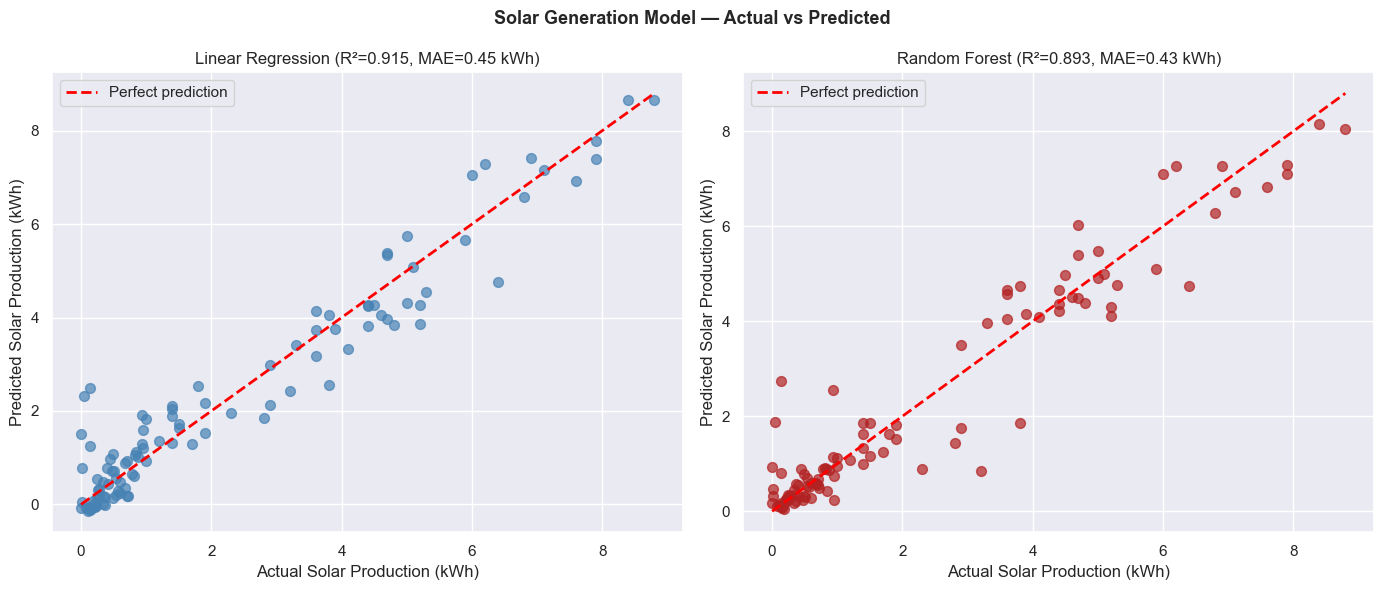

In [42]:
from sklearn.model_selection import cross_val_predict

# Get predictions using cross-validation
lr_solar.fit(X_solar, y_solar)
y_pred_lr = cross_val_predict(lr_solar, X_solar, y_solar, cv=kf)
y_pred_rf = cross_val_predict(rf_solar, X_solar, y_solar, cv=kf)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Solar Generation Model — Actual vs Predicted",
             fontsize=13, fontweight="bold")

# Left - Linear Regression
ax1.scatter(y_solar, y_pred_lr, color="steelblue", alpha=0.7, s=50)
ax1.plot([0, y_solar.max()], [0, y_solar.max()], 
         color="red", linewidth=2, linestyle="--", label="Perfect prediction")
ax1.set_title(f"Linear Regression (R²={lr_r2.mean():.3f}, MAE={-lr_mae.mean():.2f} kWh)")
ax1.set_xlabel("Actual Solar Production (kWh)")
ax1.set_ylabel("Predicted Solar Production (kWh)")
ax1.legend()

# Right - Random Forest
ax2.scatter(y_solar, y_pred_rf, color="firebrick", alpha=0.7, s=50)
ax2.plot([0, y_solar.max()], [0, y_solar.max()],
         color="red", linewidth=2, linestyle="--", label="Perfect prediction")
ax2.set_title(f"Random Forest (R²={rf_r2.mean():.3f}, MAE={-rf_mae.mean():.2f} kWh)")
ax2.set_xlabel("Actual Solar Production (kWh)")
ax2.set_ylabel("Predicted Solar Production (kWh)")
ax2.legend()

plt.tight_layout()
plt.show()

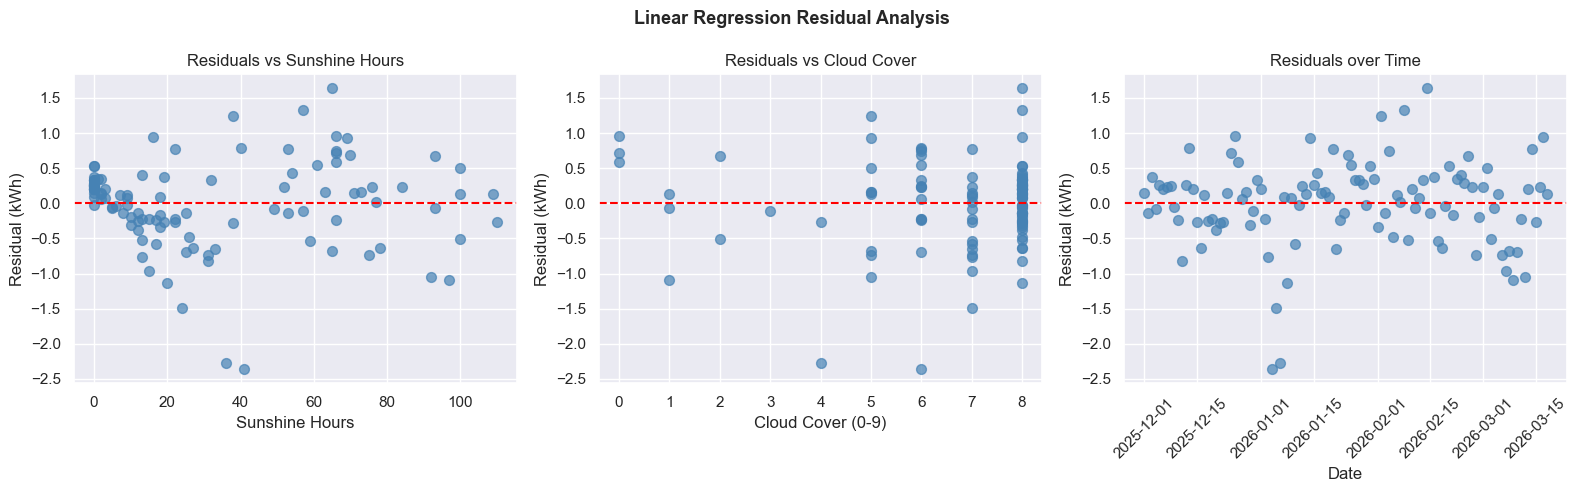

Residual summary:
  Mean: -0.001 kWh (should be ~0)
  Std:  0.619 kWh
  Max overestimate: -2.360 kWh
  Max underestimate: 1.636 kWh


In [43]:
# Calculate residuals
residuals = y_solar - y_pred_lr
residual_df = pd.DataFrame({
    "Actual": y_solar.values,
    "Predicted": y_pred_lr,
    "Residual": residuals.values,
    "Sunshine_Hours": X_solar["Sunshine_Hours"].values,
    "Solar_Irradiance": X_solar["Solar_Irradiance"].values,
    "Cloud_Cover": X_solar["Cloud_Cover"].values
}, index=solar_model_df.index)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Linear Regression Residual Analysis", fontsize=13, fontweight="bold")

# Residuals vs Sunshine Hours
axes[0].scatter(residual_df["Sunshine_Hours"], residual_df["Residual"],
                color="steelblue", alpha=0.7, s=50)
axes[0].axhline(y=0, color="red", linewidth=1.5, linestyle="--")
axes[0].set_title("Residuals vs Sunshine Hours")
axes[0].set_xlabel("Sunshine Hours")
axes[0].set_ylabel("Residual (kWh)")

# Residuals vs Cloud Cover
axes[1].scatter(residual_df["Cloud_Cover"], residual_df["Residual"],
                color="steelblue", alpha=0.7, s=50)
axes[1].axhline(y=0, color="red", linewidth=1.5, linestyle="--")
axes[1].set_title("Residuals vs Cloud Cover")
axes[1].set_xlabel("Cloud Cover (0-9)")
axes[1].set_ylabel("Residual (kWh)")

# Residuals over time
axes[2].scatter(residual_df.index, residual_df["Residual"],
                color="steelblue", alpha=0.7, s=50)
axes[2].axhline(y=0, color="red", linewidth=1.5, linestyle="--")
axes[2].set_title("Residuals over Time")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Residual (kWh)")
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"Residual summary:")
print(f"  Mean: {residuals.mean():.3f} kWh (should be ~0)")
print(f"  Std:  {residuals.std():.3f} kWh")
print(f"  Max overestimate: {residuals.min():.3f} kWh")
print(f"  Max underestimate: {residuals.max():.3f} kWh")

## Solar Generation Forecast Model — Summary

### Model Performance
| Metric | Linear Regression | Random Forest |
|--------|------------------|---------------|
| R² score | 0.915 | 0.893 |
| MAE | 0.45 kWh | 0.43 kWh |
| CV Method | 5-fold | 5-fold |

**Selected model: Linear Regression** — simpler model outperforms Random Forest, 
consistent with the underlying physics being genuinely linear (more sunshine = more solar).

### Features Used
- **Sunshine_Hours** — strongest predictor (correlation: 0.956)
- **Solar_Irradiance** — total daily radiation in kWh/m²
- **Cloud_Cover** — mean daily cloud cover (0-9 KNMI scale)

Temperature was excluded despite moderate correlation — at daily resolution in 
winter data, temperature is not a physical driver of solar production. Panel 
efficiency losses from heat are negligible below 25°C.

### Data
- 108 daily observations (Dec 2025 — Mar 2026)
- Weather data: KNMI De Bilt station (closest to property)
- Solar data: Eneco Toon smart display

### Residual Analysis
- Mean residual: -0.001 kWh — no systematic bias
- Std: 0.619 kWh — consistent with MAE
- Two outliers (~-2.5 kWh) identified as data collection gaps during 
  electrical installation work (Toon offline, solar production not recorded)

### Known Limitations & Physical Explanations for Residual Variance
1. **Panel orientation** — SW-facing panels peak in afternoon. Days with 
   identical sunshine hours but different time-of-day distribution will 
   produce different output. KNMI daily totals don't capture intra-day patterns.
2. **Inverter switch-on threshold** — GoodWe 1500-SS requires minimum DC 
   voltage to start. Low irradiance days may show zero production despite 
   KNMI recording some sunshine hours.
3. **Diffuse vs direct irradiance** — KNMI Solar_Irradiance doesn't 
   distinguish between direct and diffuse light. Panels respond differently 
   to each type.

### Next Steps
- Retrain with full year data including summer months (expected higher 
  production, possible non-linearity at high irradiance)
- Add time-of-day irradiance distribution when live GoodWe SEMS data available
- Compare against actual GoodWe inverter data vs Toon data for accuracy validation